In [1]:
from pathlib import Path
from scipy.io import loadmat
import sys
import os

# Robust path finding for data.mat
current_path = Path.cwd()
possible_data_paths = [
    current_path / 'data' / 'data.mat',
    current_path.parent / 'data' / 'data.mat',
    current_path.parent.parent / 'data' / 'data.mat',
    # Fallback absolute path
    Path('/home/luky/skola/KalmanNet-for-state-estimation/data/data.mat')
]

dataset_path = None
for p in possible_data_paths:
    if p.exists():
        dataset_path = p
        break

if dataset_path is None or not dataset_path.exists():
    print("Warning: data.mat not found automatically.")
    dataset_path = Path('data/data.mat')

print(f"Dataset path: {dataset_path}")

# Add project root to sys.path (2 levels up from debug/test)
notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
print(f"Project root added: {project_root}")

mat_data = loadmat(dataset_path)
print(mat_data.keys())


dict_keys(['__header__', '__version__', '__globals__', 'hB', 'souradniceGNSS', 'souradniceX', 'souradniceY', 'souradniceZ'])


In [2]:
import torch
import matplotlib.pyplot as plt
from utils import trainer
from utils import utils
from Systems import DynamicSystem
import Filters
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
from scipy.io import loadmat
from scipy.interpolate import RegularGridInterpolator
import random

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

device: cuda


In [3]:
mat_data = loadmat(dataset_path)

souradniceX_mapa = mat_data['souradniceX']
souradniceY_mapa = mat_data['souradniceY']
souradniceZ_mapa = mat_data['souradniceZ']
souradniceGNSS = mat_data['souradniceGNSS'] 
x_axis_unique = souradniceX_mapa[0, :]
y_axis_unique = souradniceY_mapa[:, 0]

print(f"Dimensions of 1D X axis: {x_axis_unique.shape}")
print(f"Dimensions of 1D Y axis: {y_axis_unique.shape}")
print(f"Dimensions of 2D elevation data Z: {souradniceZ_mapa.shape}")

terMap_interpolator = RegularGridInterpolator(
    (y_axis_unique, x_axis_unique),
    souradniceZ_mapa,
    bounds_error=False, 
    fill_value=np.nan
)

def terMap(px, py):
    # Query bilinear interpolation over the terrain map
    points_to_query = np.column_stack((py, px))
    return terMap_interpolator(points_to_query)

Dimensions of 1D X axis: (2500,)
Dimensions of 1D Y axis: (2500,)
Dimensions of 2D elevation data Z: (2500, 2500)


In [4]:
import torch
from Systems import DynamicSystemTAN

state_dim = 4
obs_dim = 3
dT = 1
q = 1

F = torch.tensor([[1.0, 0.0, dT, 0.0],
                   [0.0, 1.0, 0.0, dT],
                   [0.0, 0.0, 1.0, 0.0],
                   [0.0, 0.0, 0.0, 1.0]])

Q = q* torch.tensor([[dT**3/3, 0.0, dT**2/2, 0.0],
                   [0.0, dT**3/3, 0.0, dT**2/2],
                   [dT**2/2, 0.0, dT, 0.0],
                   [0.0, dT**2/2, 0.0, dT]])
R = torch.tensor([[3.0**2, 0.0, 0.0],
                   [0.0, 1.0**2, 0.0],
                   [0.0, 0.0, 1.0**2]])

initial_velocity_np = souradniceGNSS[:2, 1] - souradniceGNSS[:2, 0]
# initial_velocity_np = torch.from_numpy()
initial_velocity = torch.from_numpy(np.array([0,0]))

initial_position = torch.from_numpy(souradniceGNSS[:2, 0])
x_0 = torch.cat([
    initial_position,
    initial_velocity
]).float()
print(x_0)

P_0 = torch.tensor([[25.0, 0.0, 0.0, 0.0],
                    [0.0, 25.0, 0.0, 0.0],
                    [0.0, 0.0, 0.5, 0.0],
                    [0.0, 0.0, 0.0, 0.5]])
import torch.nn.functional as func

def h_nl_differentiable(x: torch.Tensor, map_tensor, x_min, x_max, y_min, y_max) -> torch.Tensor:
    batch_size = x.shape[0]

    px = x[:, 0]
    py = x[:, 1]

    px_norm = 2.0 * (px - x_min) / (x_max - x_min) - 1.0
    py_norm = 2.0 * (py - y_min) / (y_max - y_min) - 1.0

    sampling_grid = torch.stack((px_norm, py_norm), dim=1).view(batch_size, 1, 1, 2)

    vyska_terenu_batch = func.grid_sample(
        map_tensor.expand(batch_size, -1, -1, -1),
        sampling_grid, 
        mode='bilinear', 
        padding_mode='border',
        align_corners=True
    )

    vyska_terenu = vyska_terenu_batch.view(batch_size)

    eps = 1e-12
    vx_w, vy_w = x[:, 2], x[:, 3]
    norm_v_w = torch.sqrt(vx_w**2 + vy_w**2).clamp(min=eps)
    cos_psi = vx_w / norm_v_w
    sin_psi = vy_w / norm_v_w

    vx_b = cos_psi * vx_w - sin_psi * vy_w 
    vy_b = sin_psi * vx_w + cos_psi * vy_w

    result = torch.stack([vyska_terenu, vx_b, vy_b], dim=1)

    return result

x_axis_unique = souradniceX_mapa[0, :]
y_axis_unique = souradniceY_mapa[:, 0]
terMap_tensor = torch.from_numpy(souradniceZ_mapa).float().unsqueeze(0).unsqueeze(0).to(device)
x_min, x_max = x_axis_unique.min(), x_axis_unique.max()
y_min, y_max = y_axis_unique.min(), y_axis_unique.max()

h_wrapper = lambda x: h_nl_differentiable(
    x, 
    map_tensor=terMap_tensor, 
    x_min=x_min, 
    x_max=x_max, 
    y_min=y_min, 
    y_max=y_max
)

system_model = DynamicSystemTAN(
    state_dim=state_dim,
    obs_dim=obs_dim,
    Q=Q.float(),
    R=R.float(),
    Ex0=x_0.float(),
    P0=P_0.float(),
    F=F.float(),
    h=h_wrapper,
    x_axis_unique=x_axis_unique, 
    y_axis_unique=y_axis_unique,
    device=device
)

tensor([1487547.1250, 6395520.5000,       0.0000,       0.0000])
INFO: DynamicSystemTAN inicializován s hranicemi mapy:
  X: [1476611.42, 1489541.47]
  Y: [6384032.63, 6400441.34]


In [5]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from utils import utils
import torch
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import os
import random
from copy import deepcopy
from state_NN_models import TAN
from utils import trainer 

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)


In [6]:
import torch
from torch.utils.data import TensorDataset, DataLoader
import os
from utils import trainer # Předpokládám, že toto máš


class NavigationDataManager:
    def __init__(self, data_dir):
        self.data_dir = data_dir
        
    def get_dataloader(self, seq_len, split='train', shuffle=True, batch_size=32, limit_samples=None):
        path = os.path.join(self.data_dir, f'len_{seq_len}', f'{split}.pt')
        
        if not os.path.exists(path):
            raise FileNotFoundError(f"❌ Dataset nenalezen: {path}")
            
        data = torch.load(path)
        x = data['x'] 
        y = data['y'] 

        # --- NEW LOGIC: Slice the tensors if a limit is provided ---
        if limit_samples is not None:
            # Ensure we don't try to slice beyond the available data
            actual_limit = min(limit_samples, len(x))
            x = x[:actual_limit]
            y = y[:actual_limit]
            print(f"   [Info] Omezeno na {actual_limit} vzorků z celkových {len(data['x'])} pro {split}.")

        dataset = TensorDataset(x, y)
        
        return DataLoader(
        dataset, 
        batch_size=batch_size, 
        shuffle=shuffle,
        num_workers=4,         # <--- Uses 4 CPU cores to prep data
        pin_memory=True,       # <--- Speeds up RAM to VRAM transfer
        persistent_workers=True # <--- Keeps workers alive between epochs
    )
# OPTIMIZED MATRIX MULTIPLICATION:
torch.set_float32_matmul_precision('high')
DATA_DIR = './generated_data_synthetic_controlled-extended-trajectories-harder'

data_manager = NavigationDataManager(DATA_DIR)

# Definice fází (zde řídíš, jak se trénink vyvíjí)
curriculum_schedule = [
    # FÁZE 1: Warm-up (Krátké sekvence)
    {
        'phase_id': 1,
        'seq_len': 10,          
        'epochs': 500,           
        'lr': 1e-3, 
        'batch_size': 256
    },
    
    # FÁZE 2: Stabilizace (Střední délka)
    {
        'phase_id': 2,
        'seq_len': 100, 
        'epochs': 200, 
        'lr': 1e-4,             
        'batch_size': 64
    },
    
    # FÁZE 3: Long-term Reality (Plná délka)
    {
        'phase_id': 3,
        'seq_len': 300,         
        'epochs': 200, 
        'lr': 1e-5,             
        'batch_size': 64       # Menší batch kvůli paměti GPU u dlouhých sekvencí
    },
        {
        'phase_id': 4,
        'seq_len': 500,         
        'epochs': 200, 
        'lr': 5e-6,             
        'batch_size': 32       # Menší batch kvůli paměti GPU u dlouhých sekvencí
    }
]

datasets_cache = {} 
TRAIN_LIMIT = 2000 # Define your limit here

for phase in curriculum_schedule:
    seq_len = phase['seq_len']
    bs = phase['batch_size']
    
    print(f"📥 Načítám Fázi {phase['phase_id']}: Seq={seq_len} | Batch={bs} ...")
    
    try:
        # Pass the limit_samples parameter ONLY to the train loader
        train_loader = data_manager.get_dataloader(
            seq_len=seq_len, split='train', shuffle=True, batch_size=bs, limit_samples=TRAIN_LIMIT
        )
        
        # Validation loader usually loads everything available
        val_loader = data_manager.get_dataloader(
            seq_len=seq_len, split='val', shuffle=False, batch_size=bs
        )
        
        datasets_cache[phase['phase_id']] = (train_loader, val_loader)

        x_ex, y_ex = next(iter(train_loader))
        print(f"   Úspěšně načteno. Train batch shape: {x_ex.shape}")
     
    except FileNotFoundError as e:
        print(f"   ⚠️ error: {e}")

c:\Users\PC1\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:85.)
  _C._set_float32_matmul_precision(precision)


📥 Načítám Fázi 1: Seq=10 | Batch=256 ...
   [Info] Omezeno na 2000 vzorků z celkových 2500 pro train.
   Úspěšně načteno. Train batch shape: torch.Size([256, 10, 4])
📥 Načítám Fázi 2: Seq=100 | Batch=64 ...
   [Info] Omezeno na 2000 vzorků z celkových 2500 pro train.
   Úspěšně načteno. Train batch shape: torch.Size([64, 100, 4])
📥 Načítám Fázi 3: Seq=300 | Batch=64 ...
   [Info] Omezeno na 2000 vzorků z celkových 2500 pro train.
   Úspěšně načteno. Train batch shape: torch.Size([64, 300, 4])
📥 Načítám Fázi 4: Seq=500 | Batch=32 ...
   [Info] Omezeno na 2000 vzorků z celkových 2500 pro train.
   Úspěšně načteno. Train batch shape: torch.Size([32, 500, 4])


In [7]:
import torch
import torch.nn.functional as F
import numpy as np
import os
import gc
from copy import deepcopy

# ==============================================================================
# 1. POMOCNÉ FUNKCE (ANEES)
# ==============================================================================
def calculate_anees_vectorized(x_true: torch.Tensor, x_hat: torch.Tensor, P_hat: torch.Tensor) -> float:
    error = x_true - x_hat  
    B, Seq, Dim = error.shape
    error_flat = error.reshape(B * Seq, Dim, 1)
    P_hat_flat = P_hat.reshape(B * Seq, Dim, Dim)
    
    eye = torch.eye(Dim, device=P_hat.device, dtype=P_hat.dtype).unsqueeze(0).expand(B * Seq, -1, -1)
    P_hat_stable = P_hat_flat + 1e-6 * eye
    
    try:
        y = torch.linalg.solve(P_hat_stable, error_flat)
    except RuntimeError as e:
        print(f"⚠️ Varování při výpočtu ANEES (Singulární matice). Fallback na pseudoinverzi: {e}")
        P_inv = torch.linalg.pinv(P_hat_stable)
        y = torch.bmm(P_inv, error_flat)
        
    error_flat_T = error_flat.transpose(1, 2)
    nees = torch.bmm(error_flat_T, y).squeeze()
    return nees.mean().item()

# ==============================================================================
# 2. TRÉNOVACÍ FUNKCE S TBPTT (Bayesian Hybrid)
# ==============================================================================
def train_BayesianKalmanNet_Hybrid(
    model, train_loader, val_loader, device,
    total_train_iter, learning_rate, clip_grad,
    J_samples, validation_period, logging_period,
    warmup_iterations=0, 
    weight_decay_=1e-5,
    lambda_mse=1.0, 
    calibration_parameter=0.0,
    force_seq_len=None,
    add_noise=False,
    tbptt_w=20, # <--- TBPTT DELKA OKNA (pro TAN ideálně 20)
    tbptt_k=2   # <--- TBPTT FREKVENCE ODPOJENÍ
):
    p_logits_params = []
    base_params = []
    
    for name, param in model.named_parameters():
        if 'p_logit' in name:
            p_logits_params.append(param)
        else:
            base_params.append(param)

    optimizer = torch.optim.AdamW([
        {'params': base_params, 'lr': learning_rate, 'weight_decay': weight_decay_},
        {'params': p_logits_params, 'lr': 1e-3, 'weight_decay': 0.0} 
    ])

    best_hybrid_score = float('inf')
    best_iter_count = 0
    best_model_state = None
    
    best_val_mse = float('inf')
    best_val_anees = float('inf')

    train_iter_count = 0
    done = False

    running_loss, running_mse, running_nll = 0.0, 0.0, 0.0
    steps_since_val = 0

    print(f"🚀 START Bayesian TBPTT Training | Cíl: {total_train_iter} iterací")
    print(f"    📏 TBPTT Nastavení: Window(w)={tbptt_w}, Detach(k)={tbptt_k}")
    if force_seq_len: print(f"    ✂️  Ořez dat: Max délka sekvence = {force_seq_len}")
    print("-" * 100)

    while not done:
        model.train()
        for x_true_batch, y_meas_batch in train_loader:
            if train_iter_count >= total_train_iter: done = True; break
            
            if force_seq_len is not None and x_true_batch.shape[1] > force_seq_len:
                if model.training:
                    max_start = x_true_batch.shape[1] - force_seq_len
                    start_idx = torch.randint(0, max_start + 1, (1,)).item()
                else:
                    start_idx = 0
                x_true_batch = x_true_batch[:, start_idx:start_idx+force_seq_len, :]
                y_meas_batch = y_meas_batch[:, start_idx:start_idx+force_seq_len, :]
            
            if torch.isnan(x_true_batch).any(): continue
            
            x_true_batch = x_true_batch.to(device)
            y_meas_batch = y_meas_batch.to(device)
            batch_size, seq_len, state_dim = x_true_batch.shape
            
            # --- 1. SETUP MC BATCH ---
            mc_batch_size = batch_size * J_samples
            x_true_mc = x_true_batch.repeat(J_samples, 1, 1)
            y_meas_mc = y_meas_batch.repeat(J_samples, 1, 1)
            initial_states = x_true_mc[:, 0, :]

            if add_noise:
                noise_std = torch.tensor([3.5, 3.5, 0.5, 0.5], device=device).unsqueeze(0).expand_as(initial_states)
                noisy_initial_states = initial_states + (torch.randn_like(initial_states) * noise_std)
            else:
                noisy_initial_states = initial_states

            model.reset(batch_size=mc_batch_size, initial_state=noisy_initial_states)
            
            total_loss_for_batch, total_mse_for_batch, total_nll_for_batch = 0.0, 0.0, 0.0
            num_windows = 0

            # ==========================================
            # 2. SLIDING WINDOW TBPTT (Backprop po oknech)
            # ==========================================
            for t_start in range(1, seq_len, tbptt_w):
                t_end = min(t_start + tbptt_w, seq_len)
                window_len = t_end - t_start
                if window_len == 0: continue

                predictions_x = []
                regs = []

                # Průchod aktuálním oknem
                for t in range(t_start, t_end):
                    y_t = y_meas_mc[:, t, :]
                    x_filtered_t, reg_t = model.step(y_t)
                    predictions_x.append(x_filtered_t)
                    regs.append(reg_t)

                    # TBPTT Detach uvnitř okna
                    if (t - t_start + 1) % tbptt_k == 0:
                        model.detach_hidden()

                # TBPTT Detach na konci okna před backprop
                model.detach_hidden()

                # Zpracování odhadů okna (průměr přes J_samples)
                all_x_hats_flat = torch.stack(predictions_x, dim=1)
                all_x_hats = all_x_hats_flat.view(J_samples, batch_size, window_len, state_dim)
                x_hat_sequence = all_x_hats.mean(dim=0)
                
                # Výpočet kovariance
                x_centered = all_x_hats - x_hat_sequence.unsqueeze(0)
                cov_full_sequence = (1.0 / (J_samples - 1)) * torch.einsum('jbtd,jbtk->btdk', x_centered, x_centered)
                cov_diag_sequence = torch.diagonal(cov_full_sequence, dim1=-2, dim2=-1) + 1e-3 
                
                regularization_loss = torch.stack(regs).mean()
                target_sequence = x_true_batch[:, t_start:t_end, :]

                # A) Klasické MSE pro polohu
                mse_loss = F.mse_loss(x_hat_sequence, target_sequence)
                
                # B) Stop-gradient MSE pro stabilní NLL (odpojené MSE)
                error_sq_detached = (x_hat_sequence.detach() - target_sequence) ** 2
                
                # C) Beta-NLL
                beta = 0.5
                nll_elementwise = 0.5 * (torch.log(cov_diag_sequence) + error_sq_detached / cov_diag_sequence)
                beta_scale = (cov_diag_sequence.detach() ** beta)
                beta_nll_loss = (nll_elementwise * beta_scale).mean()
                
                # D) Celková Hybridní Ztráta pro Okno
                # Pokud ještě probíhá MSE Warmup, potlačíme NLL na nulu
                current_nll_weight = 1.0 if train_iter_count >= warmup_iterations else 0.0
                loss = (current_nll_weight * beta_nll_loss) + (lambda_mse * mse_loss) + regularization_loss * 1.0

                if torch.isnan(loss): continue

                # Backprop a update vah pro toto okno
                optimizer.zero_grad()
                loss.backward()
                if clip_grad > 0: torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
                optimizer.step()

                total_loss_for_batch += loss.item()
                total_mse_for_batch += mse_loss.item()
                total_nll_for_batch += beta_nll_loss.item()
                num_windows += 1

            if num_windows > 0:
                running_loss += (total_loss_for_batch / num_windows)
                running_mse += (total_mse_for_batch / num_windows)
                running_nll += (total_nll_for_batch / num_windows)
                steps_since_val += 1
                train_iter_count += 1

            # ==========================================
            # 3. VALIDACE A LOGOVÁNÍ
            # ==========================================
            if train_iter_count > 0 and train_iter_count % validation_period == 0:
                avg_t_loss = running_loss / steps_since_val
                avg_t_mse = running_mse / steps_since_val
                avg_t_nll = running_nll / steps_since_val
                
                running_loss, running_mse, running_nll, steps_since_val = 0.0, 0.0, 0.0, 0
                
                model.eval()
                val_mse_list, val_pos_std_list = [], []
                all_val_x_true, all_val_x_hat, all_val_P_hat = [], [], []

                with torch.no_grad():
                    p1 = torch.sigmoid(model.dnn.concrete_dropout1.p_logit).item()
                    p2 = torch.sigmoid(model.dnn.concrete_dropout2.p_logit).item()

                    for x_true_val, y_meas_val in val_loader:
                        if force_seq_len is not None and x_true_val.shape[1] > force_seq_len:
                            x_true_val = x_true_val[:, :force_seq_len, :]
                            y_meas_val = y_meas_val[:, :force_seq_len, :]

                        v_bs, v_seq, _ = x_true_val.shape
                        x_true_val, y_meas_val = x_true_val.to(device), y_meas_val.to(device)
                        
                        v_mc_bs = v_bs * J_samples
                        v_x_true_mc = x_true_val.repeat(J_samples, 1, 1)
                        v_y_meas_mc = y_meas_val.repeat(J_samples, 1, 1)
                        
                        model.reset(batch_size=v_mc_bs, initial_state=v_x_true_mc[:, 0, :])
                        
                        v_x_hats_list = []
                        for t in range(1, v_seq):
                            est, _ = model.step(v_y_meas_mc[:, t, :])
                            v_x_hats_list.append(est)
                            
                        v_all_x_hats_flat = torch.stack(v_x_hats_list, dim=1)
                        v_all_x_hats = v_all_x_hats_flat.view(J_samples, v_bs, v_seq - 1, state_dim)
                        
                        val_mean = v_all_x_hats.mean(dim=0)
                        v_x_centered = v_all_x_hats - val_mean.unsqueeze(0)
                        val_covs_full = (1.0 / (J_samples - 1)) * torch.einsum('jbtd,jbtk->btdk', v_x_centered, v_x_centered)
                        
                        eye_matrix = torch.eye(state_dim, device=device).view(1, 1, state_dim, state_dim)
                        val_covs_full = val_covs_full + eye_matrix * 1e-6
                        
                        val_mse_list.append(F.mse_loss(val_mean, x_true_val[:, 1:, :]).item())
                        
                        std_px = torch.sqrt(val_covs_full[:, :, 0, 0])
                        std_py = torch.sqrt(val_covs_full[:, :, 1, 1])
                        batch_pos_std = ((std_px + std_py) / 2.0).mean().item()
                        val_pos_std_list.append(batch_pos_std)

                        full_x_hat = torch.cat([x_true_val[:, 0, :].unsqueeze(1), val_mean], dim=1)
                        P0 = model.system_model.P0.unsqueeze(0).repeat(v_bs, 1, 1).unsqueeze(1)
                        full_P_hat = torch.cat([P0, val_covs_full], dim=1)
                        
                        all_val_x_true.append(x_true_val.cpu())
                        all_val_x_hat.append(full_x_hat.cpu())
                        all_val_P_hat.append(full_P_hat.cpu())

                avg_val_mse = np.mean(val_mse_list)
                avg_val_pos_std = np.mean(val_pos_std_list) 
                
                try:
                    avg_val_anees = calculate_anees_vectorized(
                        torch.cat(all_val_x_true, dim=0),
                        torch.cat(all_val_x_hat, dim=0),
                        torch.cat(all_val_P_hat, dim=0)
                    )
                except Exception:
                    avg_val_anees = 100.0

                anees_diff = abs(avg_val_anees - state_dim)
                hybrid_score = avg_val_mse + (calibration_parameter * anees_diff)

                best_marker = ""
                if hybrid_score < best_hybrid_score:
                    best_hybrid_score = hybrid_score
                    best_iter_count = train_iter_count
                    best_val_mse = avg_val_mse
                    best_val_anees = avg_val_anees
                    best_model_state = deepcopy(model.state_dict())
                    best_marker = " ⭐ NEW BEST!"

                mode = "Warmup" if train_iter_count < warmup_iterations else "Hybrid"
                print(f"[{train_iter_count:4d}/{total_train_iter}] {mode} | "
                      f"Tr (Loss: {avg_t_loss:.2f}, MSE: {avg_t_mse:.1f}, β-NLL: {avg_t_nll:.2f}) | "
                      f"Val (MSE: {avg_val_mse:.1f}, ANEES: {avg_val_anees:.1f}) | "
                      f"Diag (σ_pos: \033[93m±{avg_val_pos_std:.1f}m\033[0m, p1: {p1:.2f}, p2: {p2:.2f}){best_marker}")
                
                model.train()

    print("-" * 100)
    print(f"✅ Trénink dokončen. Načítám nejlepší model z iterace {best_iter_count} "
          f"(Val MSE: {best_val_mse:.4f}, Val ANEES: {best_val_anees:.4f})")
    
    if best_model_state:
        model.load_state_dict(best_model_state)
    
    return {"final_model": model, "best_val_mse": best_val_mse, "best_val_anees": best_val_anees}


# ==============================================================================
# 3. HLAVNÍ CURRICULUM SETUP
# ==============================================================================
seq_len_to_idx = {
    10: 1,    
    100: 2,   
    300: 3,
    500: 4,    
}

curriculum_schedule = [
    {
        'phase_id': 1,
        'target_seq_len': 10,
        'source_data_len': 300,  
        'iters': 600,
        'lr': 1e-3,
        'lambda_mse': 1.0,       
        'clip_grad': 1.0,
        'mse_warmup_iters': 600, 
        'calibration_parameter': 0.0,
        'j_samples': 10  
    },
    {
        'phase_id': 3,
        'target_seq_len': 50,    
        'source_data_len': 300,  
        'iters': 1000,
        'lr': 5e-5,              
        'clip_grad': 0.5,
        'lambda_mse': 2.0,       
        'mse_warmup_iters': 0, 
        'calibration_parameter': 1.0,
        'j_samples': 10   
    },
    {
        'phase_id': 4,
        'target_seq_len': 100,   
        'source_data_len': 100,
        'iters': 1200,           
        'lr': 5e-5,              # UP from 1e-5
        'clip_grad': 0.25,       
        'lambda_mse': 5.0,       
        'mse_warmup_iters': 0, 
        'calibration_parameter': 1.0, 
        'j_samples': 10   
    },
    {
        'phase_id': 5,
        'target_seq_len': 300,   
        'source_data_len': 300,
        'iters': 1000,           
        'lr': 5e-5,              # UP from 1e-5
        'clip_grad': 0.25,       # UP from 0.1 (TBPTT allows safer gradient flow)
        'lambda_mse': 5.0,       
        'mse_warmup_iters': 0, 
        'calibration_parameter': 1.0, 
        'j_samples': 10   
    },
    {
        'phase_id': 6,
        'target_seq_len': 500,   
        'source_data_len': 500,
        'iters': 1000,           
        'lr': 1e-5,              # UP from 5e-6
        'clip_grad': 0.25,       # UP from 0.1
        'lambda_mse': 5.0,       
        'mse_warmup_iters': 0, 
        'calibration_parameter': 1.0, 
        'j_samples': 10   
    }
]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

state_knet2 = TAN.StateBayesianKalmanNetTAN(
        system_model=system_model, 
        device=device,
        hidden_size_multiplier=6,       # UP from 4
        output_layer_multiplier=2,
        num_gru_layers=1,
        gru_hidden_dim_multiplier=4,    # UP from 4
        init_max_dropout=0.1,           # Keep these low to prevent temporal jitter
        init_min_dropout=0.01,
        use_log_modulus=True,
        use_terrain_grad=True    
).to(device)

print(f"🚀 START CURRICULUM TRAINING ({len(curriculum_schedule)} fází)")

for phase in curriculum_schedule:
    torch.cuda.empty_cache()
    gc.collect()

    pid = phase['phase_id']
    target_len = phase['target_seq_len']
    source_len = phase['source_data_len']
    current_j_samples = phase.get('j_samples', 5)
    
    print(f"\n" + "="*60)
    print(f"🌊 FÁZE {pid}: Cílová délka {target_len} (Zdroj dat: {source_len})")
    print(f"   Parametry: LR={phase['lr']}, LambdaMSE={phase['lambda_mse']}, J_samples={current_j_samples}")
    print("="*60)
    
    try:
        cache_idx = seq_len_to_idx[source_len]
        train_loader = datasets_cache[cache_idx][0]
        val_loader = datasets_cache[cache_idx][1]
        print(f"   -> Načítám loader z datasets_cache[{cache_idx}] (původní délka dat: {source_len})")
    except KeyError:
        print(f"❌ CHYBA: Nemám definovaný index v 'seq_len_to_idx' pro délku {source_len}!")
        break
    except IndexError:
        print(f"❌ CHYBA: Index {cache_idx} neexistuje v datasets_cache!")
        break

    phase_results = train_BayesianKalmanNet_Hybrid(
        model=state_knet2,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        
        total_train_iter=phase['iters'],
        learning_rate=phase['lr'],
        warmup_iterations=phase['mse_warmup_iters'],
        clip_grad=phase['clip_grad'],
        lambda_mse=phase['lambda_mse'],
        calibration_parameter=phase.get('calibration_parameter', 0.0),
        force_seq_len=target_len, 
        
        J_samples=current_j_samples, 
        validation_period=10,
        logging_period=10,
        weight_decay_=1e-4,
        add_noise=False,
        tbptt_w=20,  # ZDE SE PŘEDÁVÁ DÉLKA OKNA
        tbptt_k=2    # ZDE SE PŘEDÁVÁ FREKVENCE ODPOJENÍ
    )
    
    if not os.path.exists("checkpoints"): os.makedirs("checkpoints")
    torch.save(state_knet2.state_dict(), f"checkpoints/bkn_phase_{pid}_len{target_len}.pth")
    print(f"✅ Fáze {pid} dokončena. Model uložen.")

print("\n🏆 CELÝ TRÉNINK DOKONČEN.")

device: cuda
Bayesian DNN initialized WITH terrain slope (+2 features)
🚀 START CURRICULUM TRAINING (5 fází)

🌊 FÁZE 1: Cílová délka 10 (Zdroj dat: 300)
   Parametry: LR=0.001, LambdaMSE=1.0, J_samples=10
   -> Načítám loader z datasets_cache[3] (původní délka dat: 300)
🚀 START Bayesian TBPTT Training | Cíl: 600 iterací
    📏 TBPTT Nastavení: Window(w)=20, Detach(k)=2
    ✂️  Ořez dat: Max délka sekvence = 10
----------------------------------------------------------------------------------------------------
[  10/600] Warmup | Tr (Loss: 318.50, MSE: 318.5, β-NLL: 25.59) | Val (MSE: 112.1, ANEES: 340.3) | Diag (σ_pos: ±2.1m, p1: 0.06, p2: 0.07) ⭐ NEW BEST!
[  20/600] Warmup | Tr (Loss: 54.28, MSE: 54.3, β-NLL: 9.73) | Val (MSE: 21.9, ANEES: 268.3) | Diag (σ_pos: ±1.6m, p1: 0.06, p2: 0.07) ⭐ NEW BEST!
[  30/600] Warmup | Tr (Loss: 13.86, MSE: 13.9, β-NLL: 5.16) | Val (MSE: 10.3, ANEES: 277.6) | Diag (σ_pos: ±1.5m, p1: 0.06, p2: 0.07) ⭐ NEW BEST!
[  40/600] Warmup | Tr (Loss: 7.24, MSE: 7

In [ ]:
if False:
    # save model.
    save_path = f'full-best_mse_bknet_with_terrain_grad-latest.pth'
    torch.save(state_knet2.state_dict(), save_path)
    print(f"Model saved to '{save_path}'.")

Model saved to 'full-best_mse_bknet_with_terrain_grad-latest.pth'.


# Test na synteticke trajektorii

=== VYHODNOCENÍ BKN NA TESTOVACÍ SADĚ (s ANEES) ===
Načítám data z: ./generated_data_synthetic_controlled-extended-trajectories-harder/test_set/test.pt
Počet testovacích trajektorií: 20
Ensemble size (BKN): 100
Délka sekvence: 1000
Modely: BKN vs. UKF vs. PF vs. APF


Evaluace:   0%|          | 0/20 [00:00<?, ?it/s]

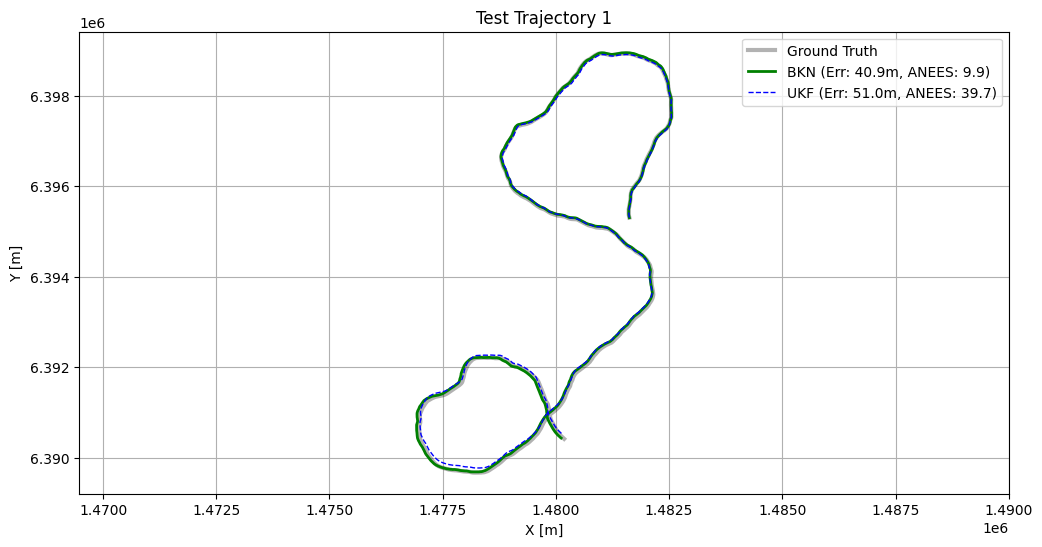

Evaluace:   5%|▌         | 1/20 [00:18<05:49, 18.42s/it]

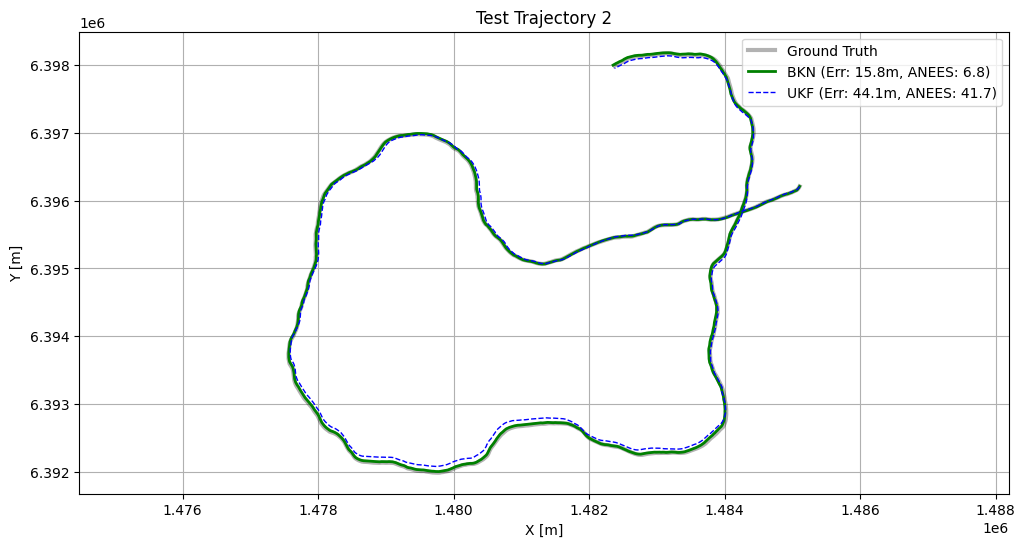

Evaluace:  10%|█         | 2/20 [00:37<05:41, 18.96s/it]

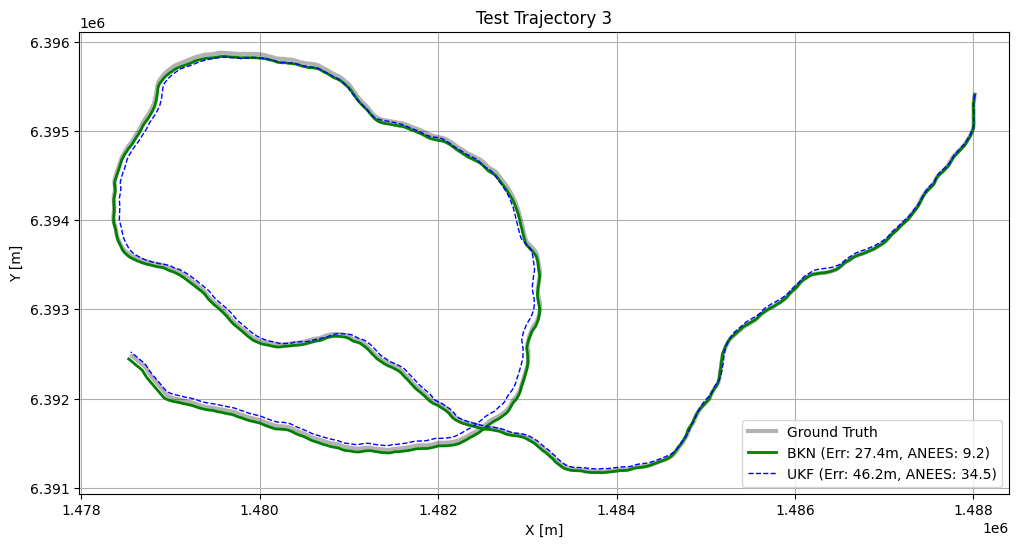

Evaluace:  15%|█▌        | 3/20 [00:59<05:42, 20.14s/it]

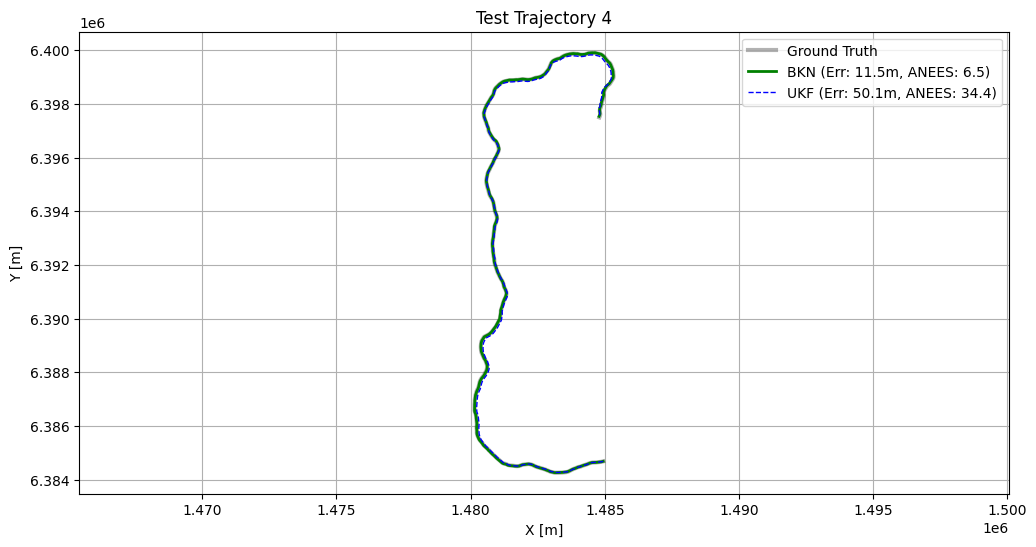

Evaluace:  20%|██        | 4/20 [01:17<05:13, 19.57s/it]

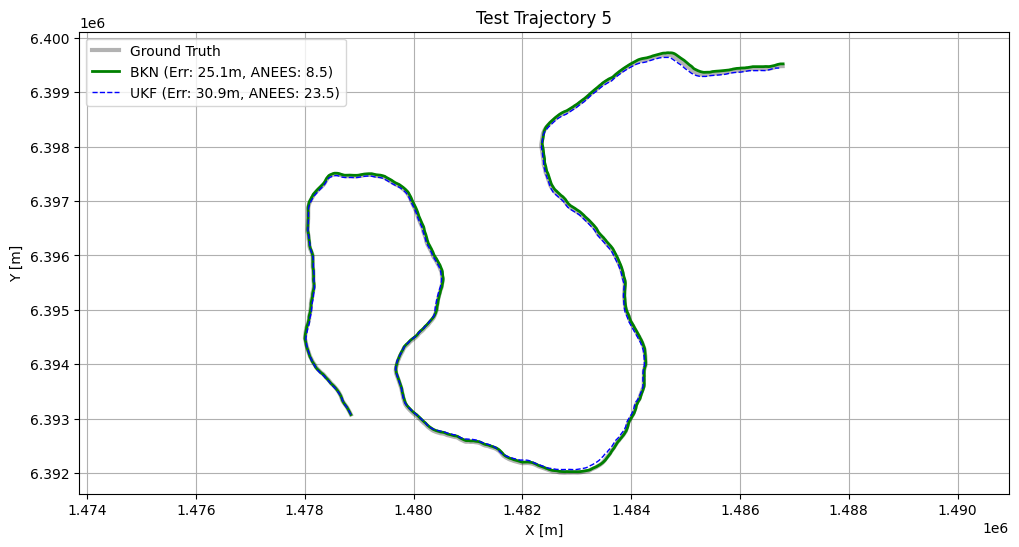

Evaluace:  25%|██▌       | 5/20 [01:36<04:46, 19.07s/it]

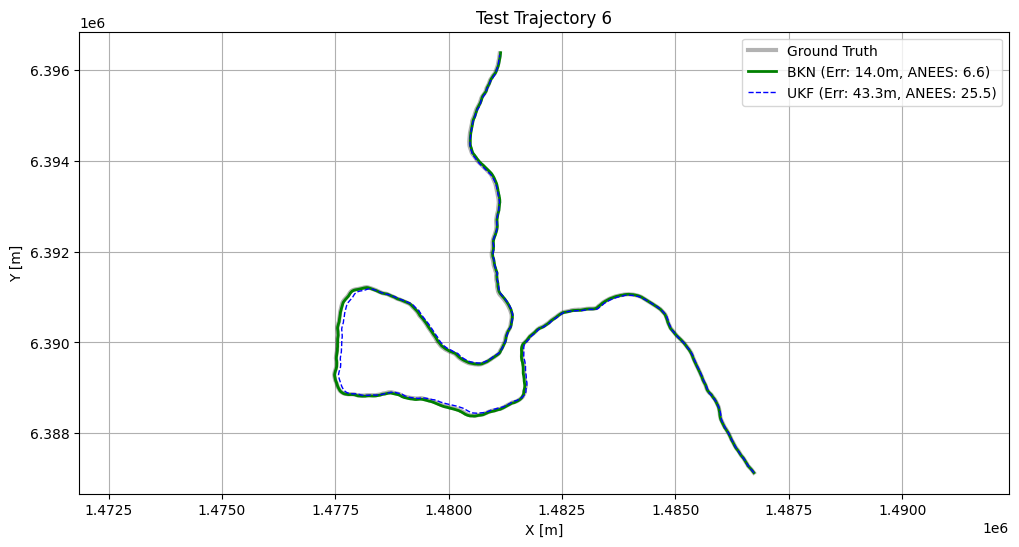

Evaluace:  30%|███       | 6/20 [01:57<04:36, 19.75s/it]

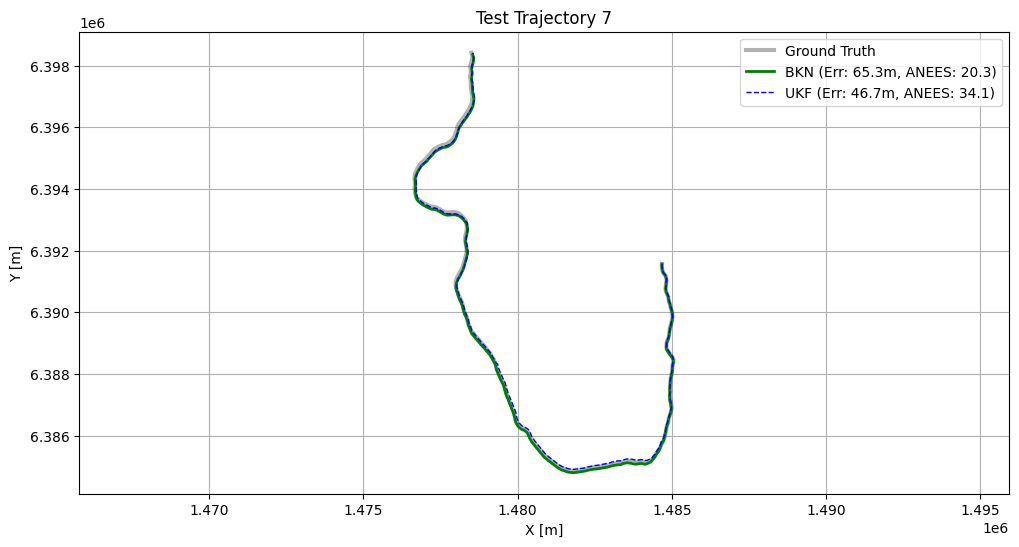

Evaluace:  35%|███▌      | 7/20 [02:15<04:11, 19.32s/it]

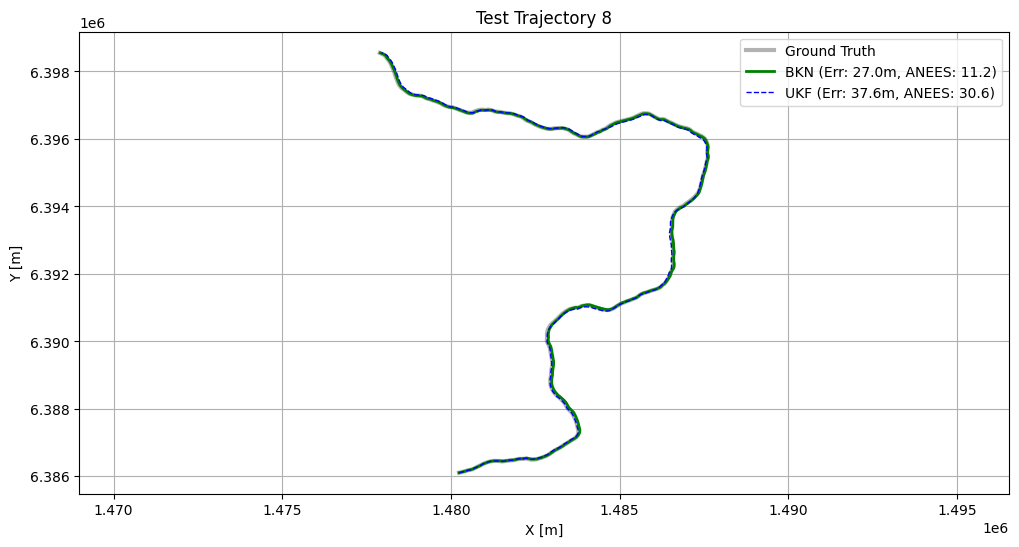

Evaluace:  40%|████      | 8/20 [02:33<03:46, 18.87s/it]

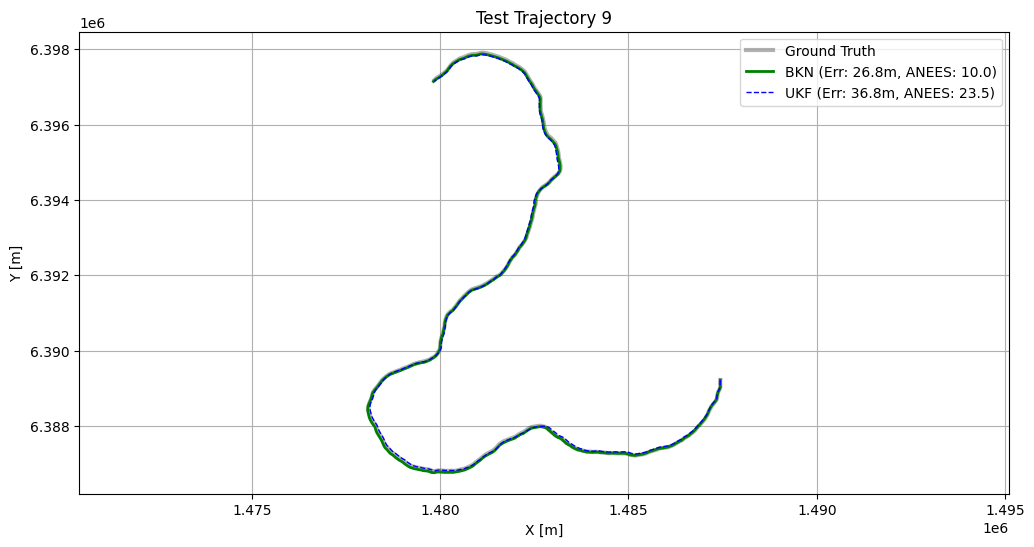

Evaluace:  45%|████▌     | 9/20 [02:53<03:32, 19.27s/it]

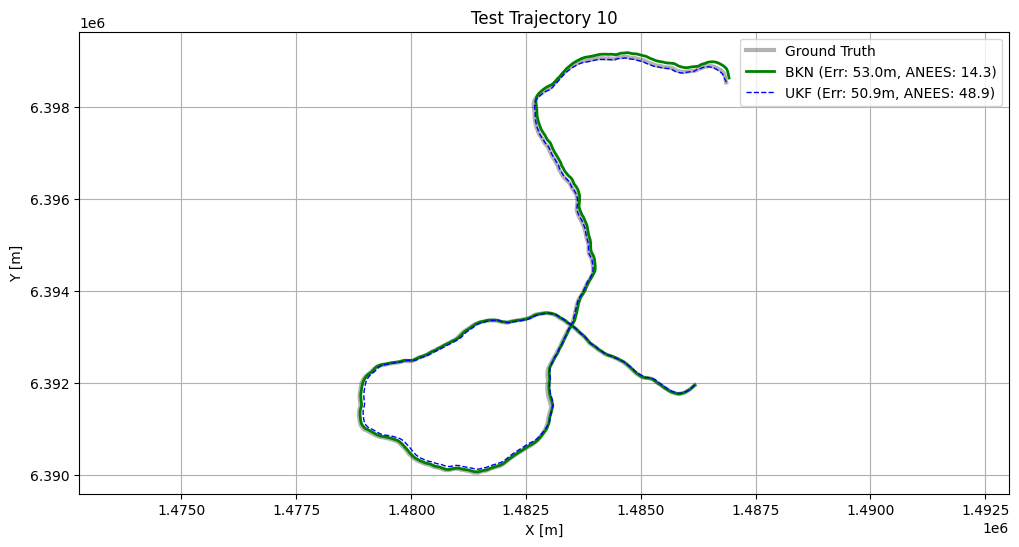

Evaluace:  50%|█████     | 10/20 [03:11<03:07, 18.80s/it]

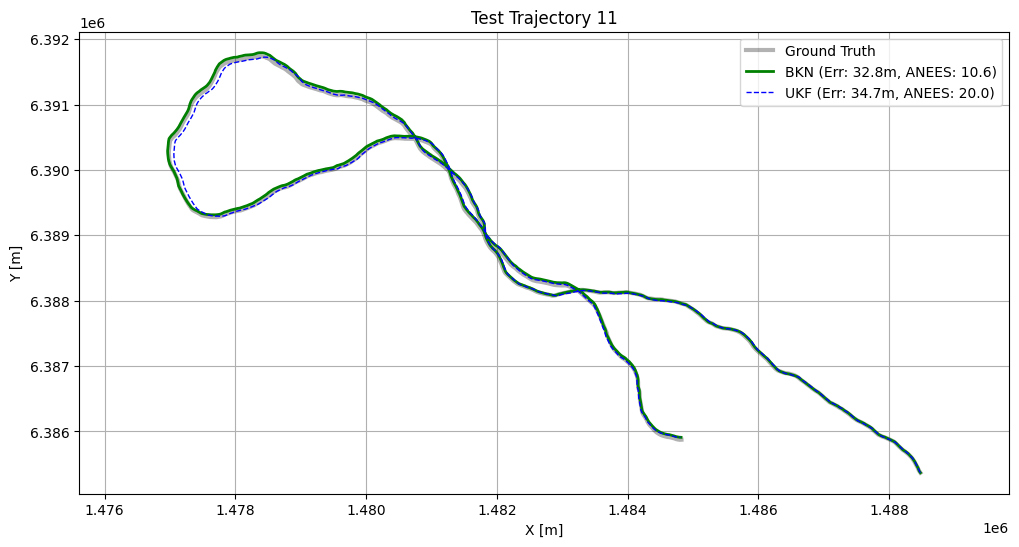

Evaluace:  55%|█████▌    | 11/20 [03:29<02:46, 18.55s/it]

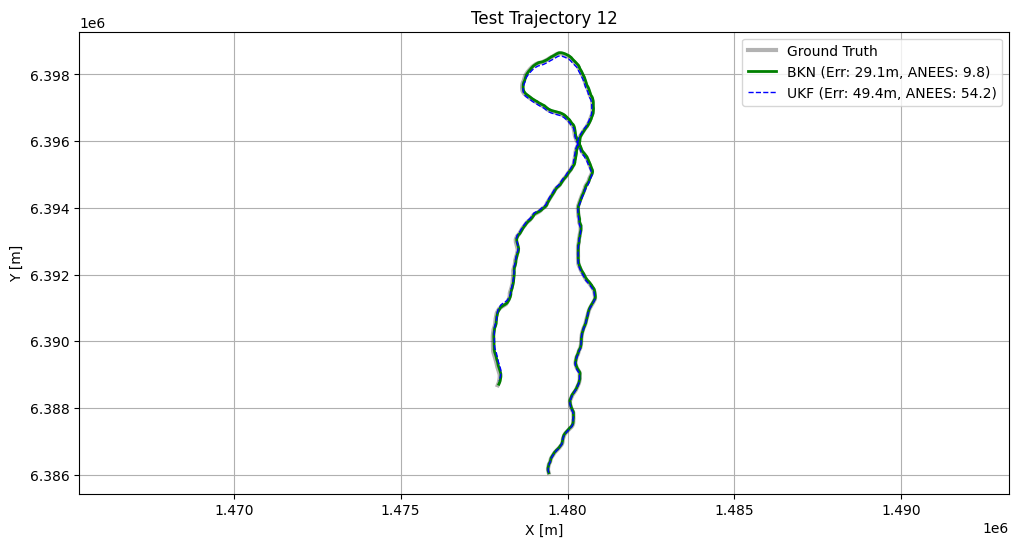

Evaluace:  60%|██████    | 12/20 [03:48<02:30, 18.80s/it]

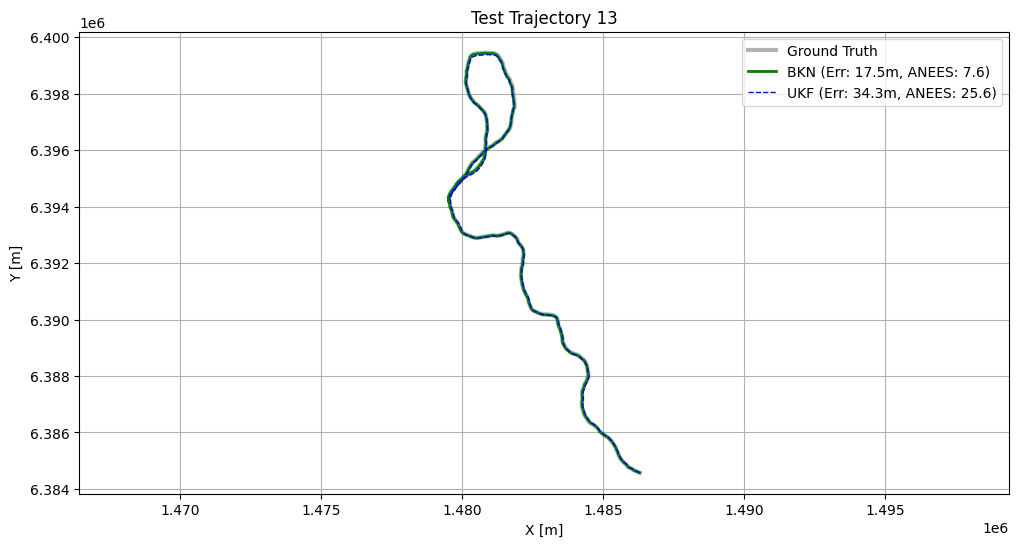

Evaluace:  65%|██████▌   | 13/20 [04:06<02:09, 18.45s/it]

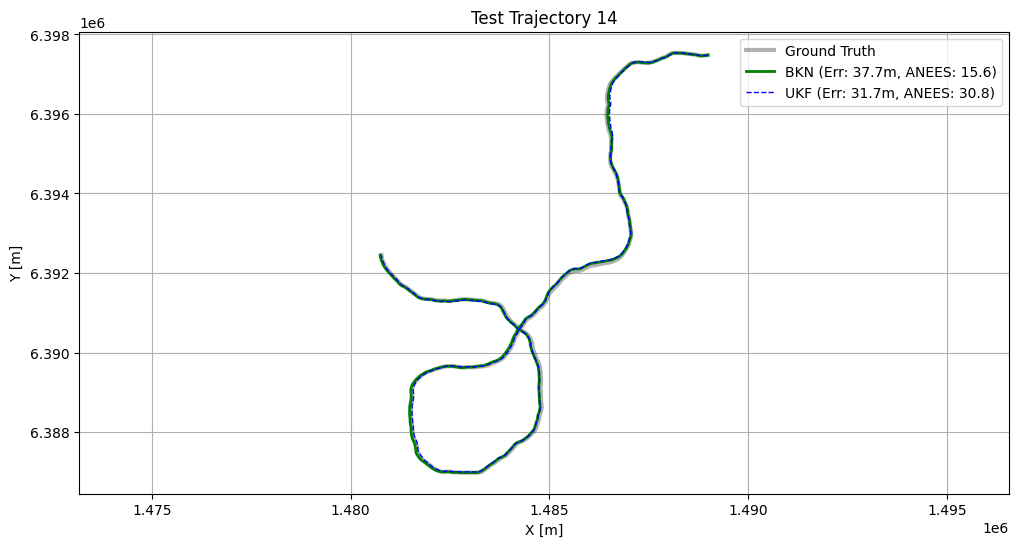

Evaluace:  70%|███████   | 14/20 [04:24<01:49, 18.23s/it]

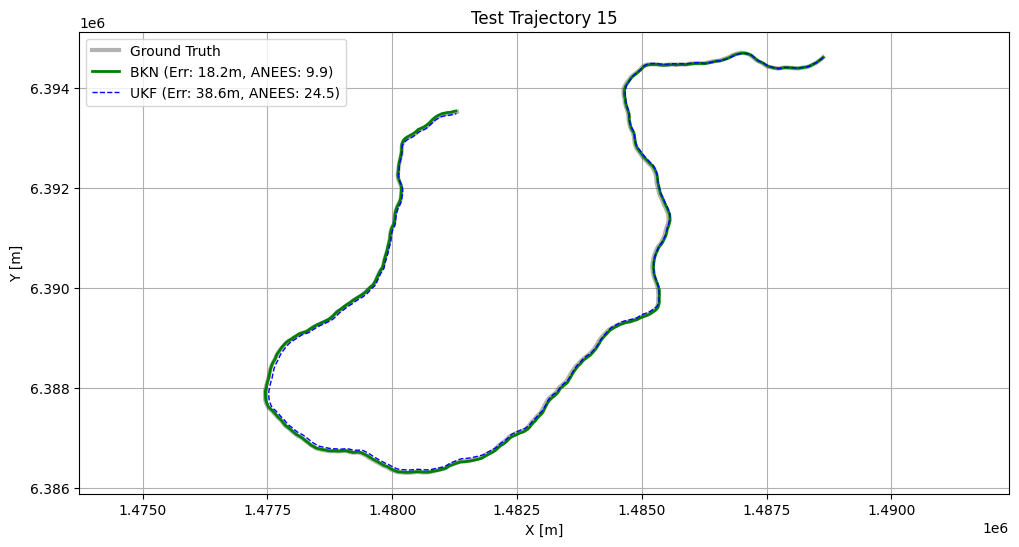

Evaluace:  75%|███████▌  | 15/20 [04:43<01:33, 18.63s/it]

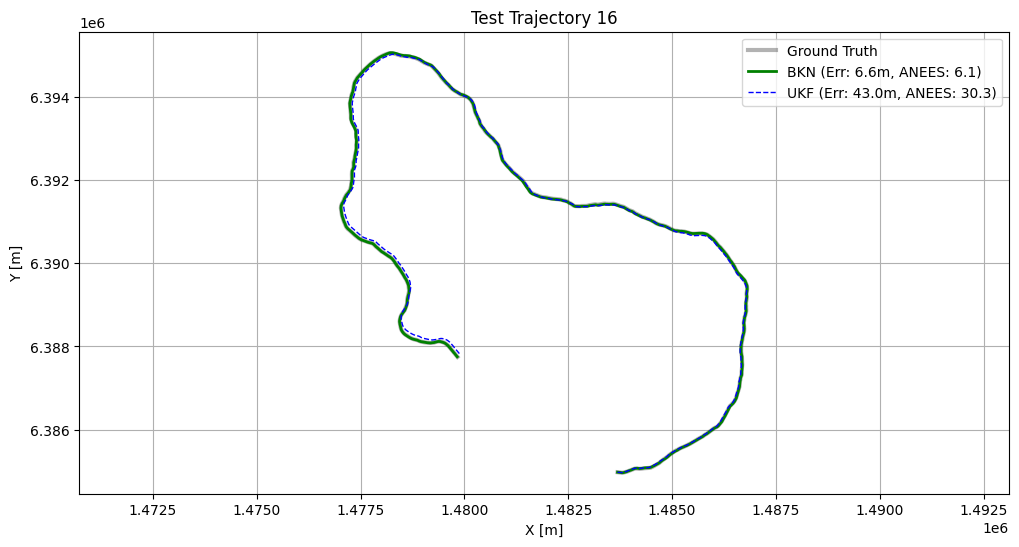

Evaluace:  80%|████████  | 16/20 [05:01<01:13, 18.29s/it]

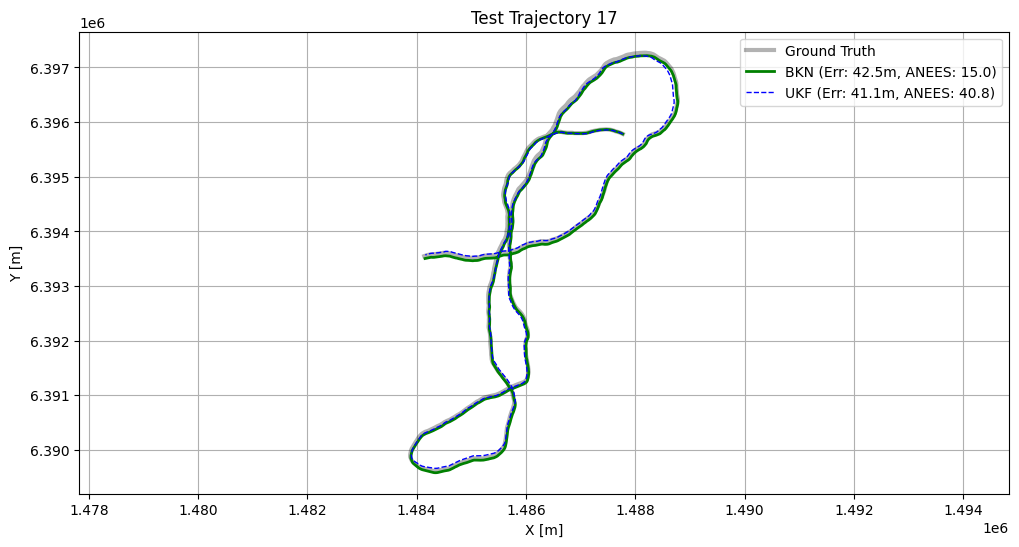

Evaluace:  85%|████████▌ | 17/20 [05:18<00:54, 18.07s/it]

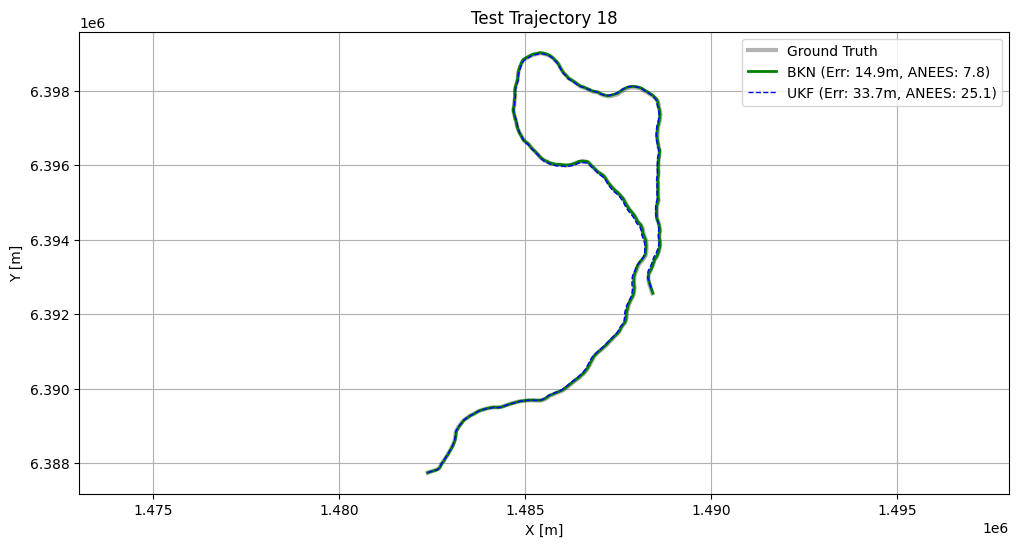

Evaluace:  90%|█████████ | 18/20 [05:38<00:37, 18.52s/it]

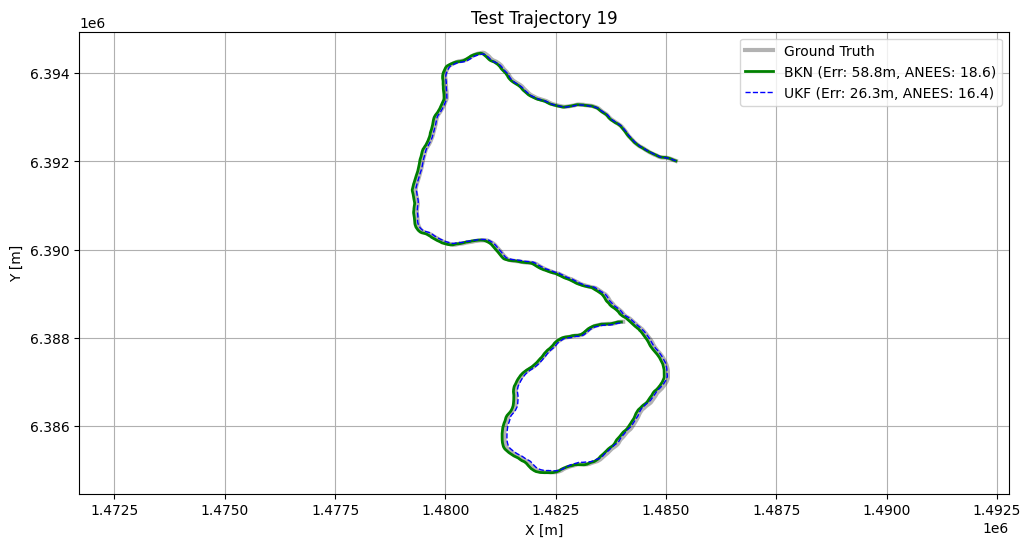

Evaluace:  95%|█████████▌| 19/20 [05:55<00:18, 18.23s/it]

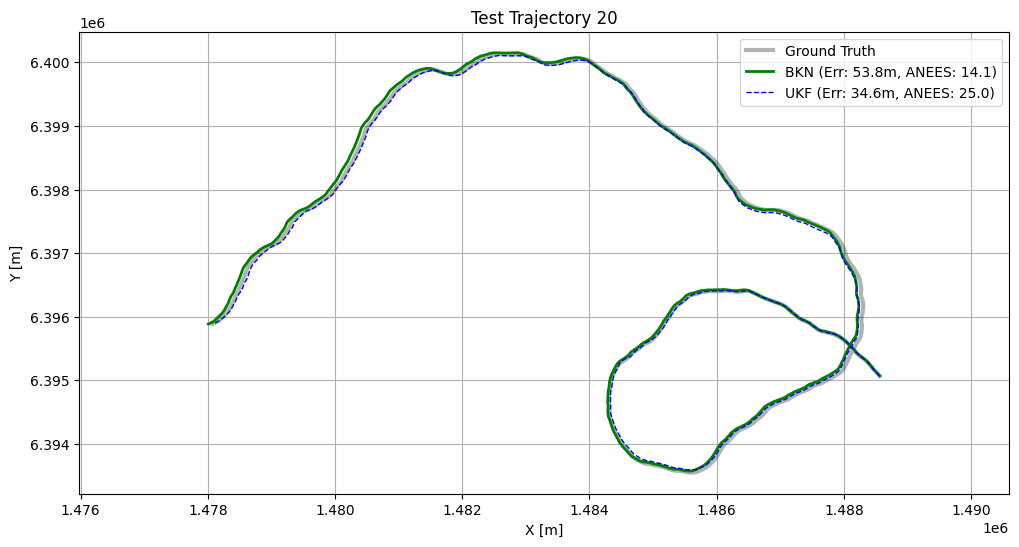

Evaluace: 100%|██████████| 20/20 [06:14<00:00, 18.70s/it]
C:\Users\PC1\AppData\Local\Temp\ipykernel_25132\90297508.py:248: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([agg_pos["BKN"], agg_pos["UKF"], agg_pos["PF"]], labels=['BKN', 'UKF', 'PF'], patch_artist=True, boxprops=dict(facecolor='lightblue'))
C:\Users\PC1\AppData\Local\Temp\ipykernel_25132\90297508.py:260: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(anees_data, labels=['BKN', 'UKF', 'PF'], patch_artist=True, boxprops=dict(facecolor='lightgreen'))



DETAILNÍ VÝSLEDKY (Pozice v metrech | ANEES - ideál ~4.0)
    Run_ID  BKN_PosErr  BKN_ANEES  UKF_PosErr  UKF_ANEES  PF_PosErr  \
0        1       40.89       9.88       50.98      39.73     111.82   
1        2       15.82       6.80       44.06      41.71     220.59   
2        3       27.38       9.18       46.22      34.50   3,317.86   
3        4       11.48       6.54       50.08      34.40     117.99   
4        5       25.05       8.54       30.94      23.53   7,475.28   
5        6       14.05       6.61       43.31      25.46      82.08   
6        7       65.27      20.25       46.67      34.07     313.96   
7        8       27.05      11.23       37.58      30.63      94.46   
8        9       26.80      10.01       36.79      23.52      62.40   
9       10       53.02      14.33       50.87      48.89     222.05   
10      11       32.84      10.59       34.73      19.97      50.25   
11      12       29.12       9.82       49.43      54.21   4,302.32   
12      13       1

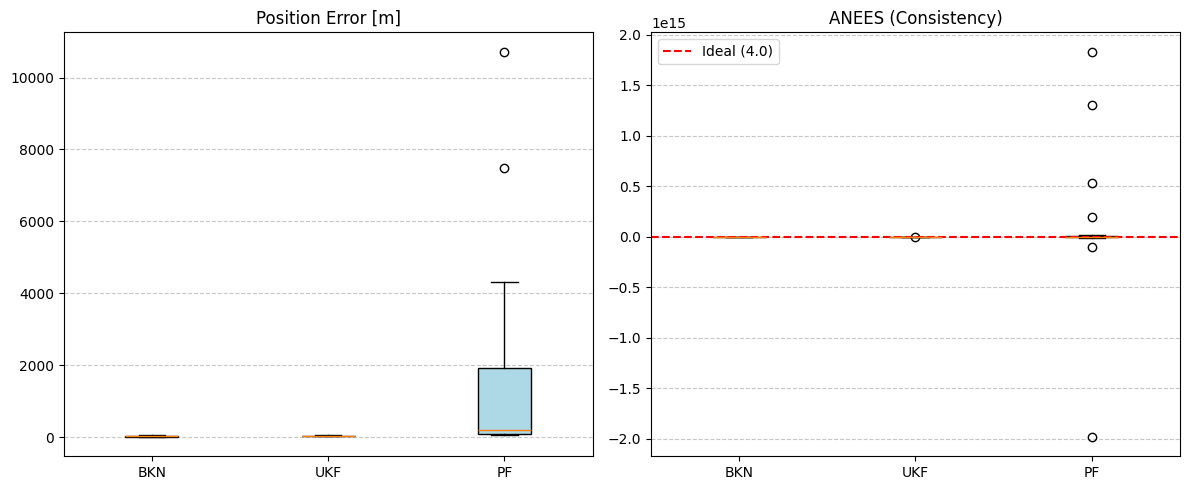

In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import Filters
import os
from tqdm import tqdm
from Filters import TAN

# === KONFIGURACE ===
TEST_DATA_PATH = './generated_data_synthetic_controlled-extended-trajectories-harder/test_set/test.pt'
PLOT_PER_ITERATION = True  # Vykreslovat graf pro každou trajektorii?
MAX_TEST_SAMPLES = 20        # Kolik trajektorií z test setu vyhodnotit
J_EVALUATION = 100           # Počet Monte Carlo vzorků pro BKN (Ensemble size)

print(f"=== VYHODNOCENÍ BKN NA TESTOVACÍ SADĚ (s ANEES) ===")
print(f"Načítám data z: {TEST_DATA_PATH}")

# 1. Načtení Testovací sady
if not os.path.exists(TEST_DATA_PATH):
    raise FileNotFoundError(f"Soubor {TEST_DATA_PATH} neexistuje!")

# Předpokládáme, že 'device' je definováno
if 'device' not in globals():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

test_data = torch.load(TEST_DATA_PATH, map_location=device)
X_test_all = test_data['x']  # Ground Truth [N, Seq, 4]
Y_test_all = test_data['y']  # Measurements [N, Seq, 3]

n_samples = min(X_test_all.shape[0], MAX_TEST_SAMPLES)
print(f"Počet testovacích trajektorií: {n_samples}")
print(f"Ensemble size (BKN): {J_EVALUATION}")
print(f"Délka sekvence: {X_test_all.shape[1]}")
print("Modely: BKN vs. UKF vs. PF vs. APF")

# 2. Inicializace pro sběr dat
detailed_results = []
trajectory_history = []
agg_mse = {"BKN": [], "UKF": [], "PF": [], "APF": []}
agg_pos = {"BKN": [], "UKF": [], "PF": [], "APF": []}
agg_anees = {"BKN": [], "UKF": [], "PF": [], "APF": []} # Nový list pro ANEES

# Ujistíme se, že BKN je v eval módu 
state_knet2.eval() 

# --- POMOCNÁ FUNKCE PRO ANEES ---
def calculate_anees(gt, est, P):
    """
    Vypočítá Average Normalized Estimation Error Squared.
    gt: Ground Truth [T, Dim] (NumPy)
    est: Odhad [T, Dim] (NumPy)
    P: Kovarianční matice [T, Dim, Dim] (NumPy)
    """
    T = min(len(gt), len(est), len(P))
    anees_vals = []
    
    # Oříznutí na stejnou délku
    gt = gt[:T]
    est = est[:T]
    P = P[:T]
    
    for t in range(T):
        e_t = gt[t] - est[t] # Chyba v čase t
        P_t = P[t]
        
        try:
            # Inverze kovariance
            # Přičteme malé epsilon na diagonálu pro numerickou stabilitu, pokud je singulární
            if np.linalg.cond(P_t) > 1e10:
                P_t = P_t + np.eye(P_t.shape[0]) * 1e-6
                
            P_inv = np.linalg.inv(P_t)
            
            # Mahalanobisova vzdálenost: e^T * P^-1 * e
            anees_t = e_t.T @ P_inv @ e_t
            anees_vals.append(anees_t)
        except np.linalg.LinAlgError:
            anees_vals.append(np.nan)
            
    return np.nanmean(anees_vals)

# --- HLAVNÍ SMYČKA ---
for i in tqdm(range(n_samples), desc="Evaluace"):
    
    # A) Příprava dat
    x_gt_tensor = X_test_all[i].to(device)
    y_obs_tensor = Y_test_all[i].to(device)
    
    x_gt = x_gt_tensor.cpu().numpy()
    seq_len = x_gt.shape[0]
    true_init_state = x_gt_tensor[0] 
    
    # --- B) BKN (Ensemble) ---
    with torch.no_grad():
        init_batch = true_init_state.unsqueeze(0).repeat(J_EVALUATION, 1)
        state_knet2.reset(batch_size=J_EVALUATION, initial_state=init_batch)
        
        bkn_preds = []
        y_input_batch = y_obs_tensor.unsqueeze(0).repeat(J_EVALUATION, 1, 1)
        
        for t in range(1, seq_len):
            y_t = y_input_batch[:, t, :]
            x_est, _ = state_knet2.step(y_t) 
            bkn_preds.append(x_est)
            
        if len(bkn_preds) > 0:
            bkn_preds_tensor = torch.stack(bkn_preds, dim=1) # [J, Seq-1, 4]
            full_bkn_ensemble = torch.cat([init_batch.unsqueeze(1), bkn_preds_tensor], dim=1) # [J, Seq, 4]
            
            # Mean Estimate
            x_est_mean = full_bkn_ensemble.mean(dim=0)
            x_est_bkn = x_est_mean.cpu().numpy()
            
            # --- VÝPOČET KOVARIANCE PRO BKN ---
            # P = 1/(J-1) * sum((x_j - x_mean) * (x_j - x_mean)^T)
            # Vycentrování
            residuals = full_bkn_ensemble - x_est_mean.unsqueeze(0) # [J, Seq, 4]
            # Permute pro batch matmul: [Seq, J, 4] a [Seq, 4, J]
            residuals = residuals.permute(1, 2, 0) # [Seq, 4, J]
            
            # Batch matrix multiplication: (Seq, 4, J) @ (Seq, J, 4) -> (Seq, 4, 4)
            P_bkn_tensor = torch.bmm(residuals, residuals.transpose(1, 2)) / (J_EVALUATION - 1)
            # Přičtení process noise/stabilitu (volitelné, BKN variance je epistemická)
            P_bkn = P_bkn_tensor.cpu().numpy()
            
        else:
            x_est_bkn = x_gt
            P_bkn = np.eye(4)[np.newaxis, :, :].repeat(len(x_gt), axis=0)

    # --- C) Klasické Filtry ---
    
    # UKF
    ukf_ideal = Filters.UnscentedKalmanFilter(system_model)
    ukf_res = ukf_ideal.process_sequence(y_seq=y_obs_tensor, Ex0=true_init_state, P0=system_model.P0)
    x_est_ukf = ukf_res['x_filtered'].cpu().numpy()
    # Získání P pro UKF (zkusíme různé klíče)
    P_ukf = ukf_res.get('P_filtered', ukf_res.get('P', None))
    if P_ukf is not None: P_ukf = P_ukf.cpu().numpy()

    # PF
    pf = TAN.ParticleFilterTAN(system_model, num_particles=1000) 
    pf_res = pf.process_sequence(y_seq=y_obs_tensor, Ex0=true_init_state, P0=system_model.P0)
    x_est_pf = pf_res['x_filtered'].cpu().numpy()
    P_pf = pf_res.get('P_filtered', pf_res.get('P', None))
    if P_pf is not None: P_pf = P_pf.cpu().numpy()

    # APF
    apf = TAN.AuxiliaryParticleFilterTAN(system_model, num_particles=2000) 
    apf_res = apf.process_sequence(y_seq=y_obs_tensor, Ex0=true_init_state, P0=system_model.P0)
    x_est_apf = apf_res['x_filtered'].cpu().numpy()
    P_apf = apf_res.get('P_filtered', apf_res.get('P', None))
    if P_apf is not None: P_apf = P_apf.cpu().numpy()
    
    # --- D) Výpočet chyb a ANEES ---
    min_len = min(len(x_gt), len(x_est_bkn), len(x_est_ukf))
    
    def calc_metrics(est, gt, P_mat):
        diff = est[:min_len] - gt[:min_len]
        mse = np.mean(np.sum(diff[:, :2]**2, axis=1)) 
        pos_err = np.mean(np.sqrt(diff[:, 0]**2 + diff[:, 1]**2))
        
        anees = np.nan
        if P_mat is not None:
            anees = calculate_anees(gt[:min_len], est[:min_len], P_mat[:min_len])
            
        return mse, pos_err, anees

    # Calculate for all
    mse_bkn, pos_bkn, anees_bkn = calc_metrics(x_est_bkn, x_gt, P_bkn)
    mse_ukf, pos_ukf, anees_ukf = calc_metrics(x_est_ukf, x_gt, P_ukf)
    mse_pf, pos_pf, anees_pf = calc_metrics(x_est_pf, x_gt, P_pf)
    mse_apf, pos_apf, anees_apf = calc_metrics(x_est_apf, x_gt, P_apf)
    
    # Uložení
    agg_mse["BKN"].append(mse_bkn); agg_pos["BKN"].append(pos_bkn); agg_anees["BKN"].append(anees_bkn)
    agg_mse["UKF"].append(mse_ukf); agg_pos["UKF"].append(pos_ukf); agg_anees["UKF"].append(anees_ukf)
    agg_mse["PF"].append(mse_pf);   agg_pos["PF"].append(pos_pf);   agg_anees["PF"].append(anees_pf)
    agg_mse["APF"].append(mse_apf); agg_pos["APF"].append(pos_apf); agg_anees["APF"].append(anees_apf)

    detailed_results.append({
        "Run_ID": i + 1,
        "BKN_PosErr": pos_bkn, "BKN_ANEES": anees_bkn,
        "UKF_PosErr": pos_ukf, "UKF_ANEES": anees_ukf,
        "PF_PosErr": pos_pf,   "PF_ANEES": anees_pf,
        "APF_PosErr": pos_apf, "APF_ANEES": anees_apf
    })
    
    if i < 2:  # Uložíme detailní časovou historii pro první 2 trajektorie
        trajectory_history.append({
            "gt": x_gt,
            "bkn_est": x_est_bkn,
            "bkn_P": P_bkn,
            "ukf_est": x_est_ukf,
            "ukf_P": P_ukf
        })
    # E) Vykreslení
    if PLOT_PER_ITERATION:
        fig = plt.figure(figsize=(12, 6))
        plt.plot(x_gt[:, 0], x_gt[:, 1], 'k-', linewidth=3, alpha=0.3, label='Ground Truth')
        plt.plot(x_est_bkn[:, 0], x_est_bkn[:, 1], 'g-', linewidth=2, label=f'BKN (Err: {pos_bkn:.1f}m, ANEES: {anees_bkn:.1f})')
        plt.plot(x_est_ukf[:, 0], x_est_ukf[:, 1], 'b--', linewidth=1, label=f'UKF (Err: {pos_ukf:.1f}m, ANEES: {anees_ukf:.1f})')
        # Pro přehlednost vykreslíme jen BKN a UKF, případně odkomentujte PF/APF
        # plt.plot(x_est_pf[:, 0], x_est_pf[:, 1], 'r:', linewidth=1, alpha=0.6, label='PF')
        plt.title(f"Test Trajectory {i+1}")
        plt.xlabel("X [m]")
        plt.ylabel("Y [m]")
        plt.legend()
        plt.axis('equal')
        plt.grid(True)
        plt.show()

# --- VÝPIS VÝSLEDKŮ ---
df_results = pd.DataFrame(detailed_results)
print("\n" + "="*120)
print(f"DETAILNÍ VÝSLEDKY (Pozice v metrech | ANEES - ideál ~4.0)")
print("="*120)
pd.options.display.float_format = '{:,.2f}'.format
print(df_results[["Run_ID", "BKN_PosErr", "BKN_ANEES", "UKF_PosErr", "UKF_ANEES", "PF_PosErr", "APF_PosErr"]])

print("\n" + "="*120)
print(f"SOUHRNNÁ STATISTIKA ({n_samples} trajektorií)")
print("="*120)

def get_stats(key):
    return (np.nanmean(agg_mse[key]), np.nanstd(agg_mse[key]), 
            np.nanmean(agg_pos[key]), np.nanstd(agg_pos[key]),
            np.nanmean(agg_anees[key]), np.nanstd(agg_anees[key]))

bkn_s = get_stats("BKN")
ukf_s = get_stats("UKF")
pf_s = get_stats("PF")
apf_s = get_stats("APF")

# Formátování tabulky
header = f"{'Model':<10} | {'Pos Error [m] (Mean ± Std)':<30} | {'ANEES (Mean ± Std)':<30}"
print(header)
print("-" * len(header))
print(f"{'BKN':<10} | {bkn_s[2]:.2f} ± {bkn_s[3]:.2f} m {'':<14} | {bkn_s[4]:.2f} ± {bkn_s[5]:.2f}")
print(f"{'UKF':<10} | {ukf_s[2]:.2f} ± {ukf_s[3]:.2f} m {'':<14} | {ukf_s[4]:.2f} ± {ukf_s[5]:.2f}")
print(f"{'PF':<10} | {pf_s[2]:.2f} ± {pf_s[3]:.2f} m {'':<14} | {pf_s[4]:.2f} ± {pf_s[5]:.2f}")
print(f"{'APF':<10} | {apf_s[2]:.2f} ± {apf_s[3]:.2f} m {'':<14} | {apf_s[4]:.2f} ± {apf_s[5]:.2f}")
print("="*120)

# Grafické porovnání (Boxplot Position Error)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.boxplot([agg_pos["BKN"], agg_pos["UKF"], agg_pos["PF"]], labels=['BKN', 'UKF', 'PF'], patch_artist=True, boxprops=dict(facecolor='lightblue'))
plt.title("Position Error [m]")
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# Grafické porovnání (Boxplot ANEES)
plt.subplot(1, 2, 2)
# Filtrujeme NaN pro boxplot
anees_data = [
    [x for x in agg_anees["BKN"] if not np.isnan(x)],
    [x for x in agg_anees["UKF"] if not np.isnan(x)],
    [x for x in agg_anees["PF"] if not np.isnan(x)]
]
plt.boxplot(anees_data, labels=['BKN', 'UKF', 'PF'], patch_artist=True, boxprops=dict(facecolor='lightgreen'))
plt.axhline(y=4.0, color='r', linestyle='--', label='Ideal (4.0)')
plt.title("ANEES (Consistency)")
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

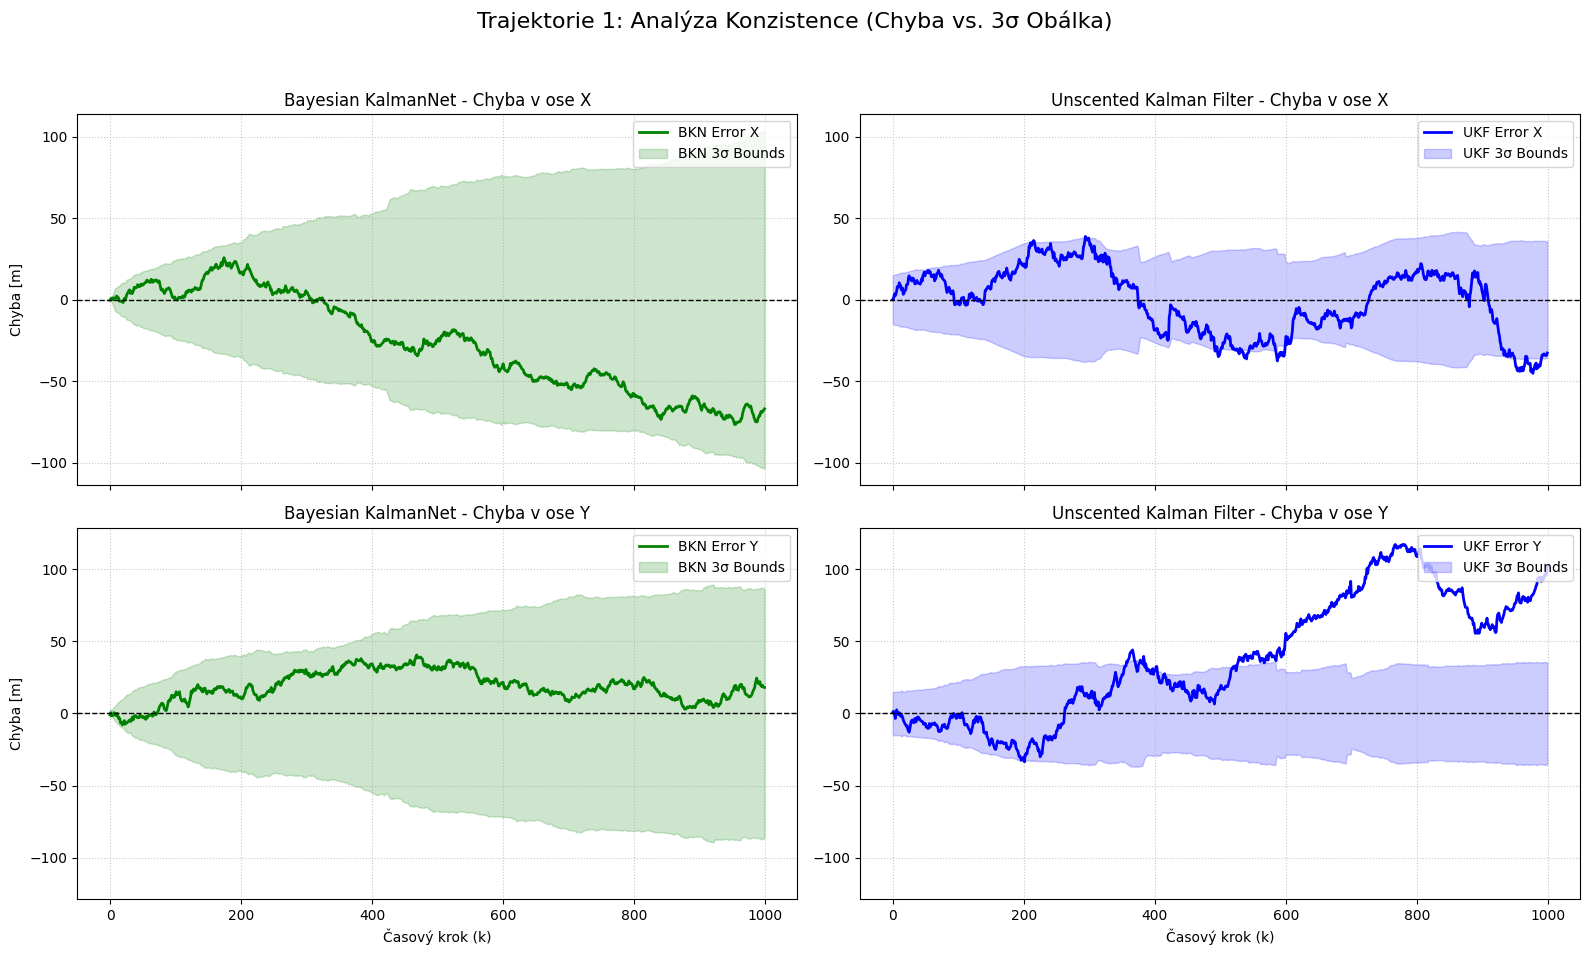

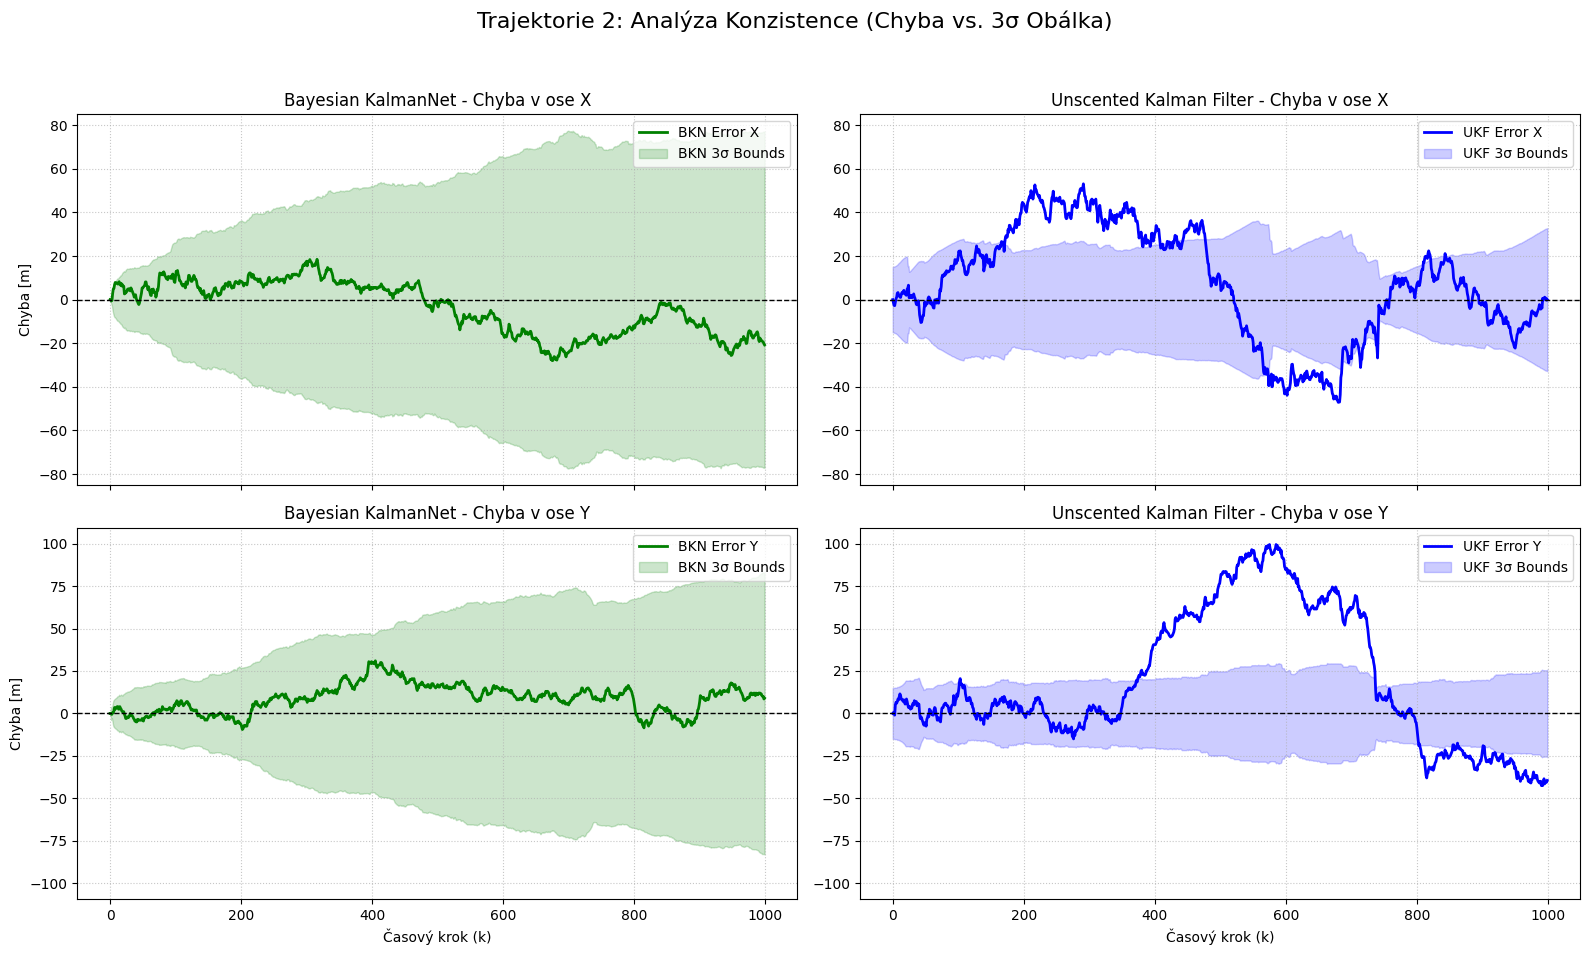

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Zkontrolujeme, zda máme uložená data z předchozí buňky
if 'trajectory_history' not in globals() or len(trajectory_history) < 2:
    print("⚠️ Chyba: Chybí data 'trajectory_history'. Ujisti se, že jsi provedl úpravu v hlavní smyčce.")
else:
    for traj_idx in range(2):
        data = trajectory_history[traj_idx]
        
        gt = data["gt"]
        bkn_est = data["bkn_est"]
        bkn_P = data["bkn_P"]
        ukf_est = data["ukf_est"]
        ukf_P = data["ukf_P"]
        
        seq_len = min(len(gt), len(bkn_est), len(ukf_est))
        time_steps = np.arange(seq_len)
        
        # Výpočet odchylek (Error = Odhad - Skutečnost)
        err_bkn_x = bkn_est[:seq_len, 0] - gt[:seq_len, 0]
        err_bkn_y = bkn_est[:seq_len, 1] - gt[:seq_len, 1]
        
        err_ukf_x = ukf_est[:seq_len, 0] - gt[:seq_len, 0]
        err_ukf_y = ukf_est[:seq_len, 1] - gt[:seq_len, 1]
        
        # Výpočet 3-sigma mezí z kovariančních matic
        # (index 0,0 je variance X; index 1,1 je variance Y)
        std_bkn_x = np.sqrt(bkn_P[:seq_len, 0, 0])
        std_bkn_y = np.sqrt(bkn_P[:seq_len, 1, 1])
        
        std_ukf_x = np.sqrt(ukf_P[:seq_len, 0, 0])
        std_ukf_y = np.sqrt(ukf_P[:seq_len, 1, 1])

        # --- VYKRESLOVÁNÍ ---
        fig, axs = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
        fig.suptitle(f'Trajektorie {traj_idx + 1}: Analýza Konzistence (Chyba vs. 3σ Obálka)', fontsize=16)

        # 1. BKN - Poloha X
        axs[0, 0].plot(time_steps, err_bkn_x, 'g-', linewidth=2, label='BKN Error X')
        axs[0, 0].fill_between(time_steps, -3*std_bkn_x, 3*std_bkn_x, color='green', alpha=0.2, label='BKN 3σ Bounds')
        axs[0, 0].axhline(0, color='black', linestyle='--', linewidth=1)
        axs[0, 0].set_title('Bayesian KalmanNet - Chyba v ose X')
        axs[0, 0].set_ylabel('Chyba [m]')
        axs[0, 0].legend(loc='upper right')
        axs[0, 0].grid(True, linestyle=':', alpha=0.7)

        # 2. BKN - Poloha Y
        axs[1, 0].plot(time_steps, err_bkn_y, 'g-', linewidth=2, label='BKN Error Y')
        axs[1, 0].fill_between(time_steps, -3*std_bkn_y, 3*std_bkn_y, color='green', alpha=0.2, label='BKN 3σ Bounds')
        axs[1, 0].axhline(0, color='black', linestyle='--', linewidth=1)
        axs[1, 0].set_title('Bayesian KalmanNet - Chyba v ose Y')
        axs[1, 0].set_xlabel('Časový krok (k)')
        axs[1, 0].set_ylabel('Chyba [m]')
        axs[1, 0].legend(loc='upper right')
        axs[1, 0].grid(True, linestyle=':', alpha=0.7)

        # 3. UKF - Poloha X
        axs[0, 1].plot(time_steps, err_ukf_x, 'b-', linewidth=2, label='UKF Error X')
        axs[0, 1].fill_between(time_steps, -3*std_ukf_x, 3*std_ukf_x, color='blue', alpha=0.2, label='UKF 3σ Bounds')
        axs[0, 1].axhline(0, color='black', linestyle='--', linewidth=1)
        axs[0, 1].set_title('Unscented Kalman Filter - Chyba v ose X')
        axs[0, 1].legend(loc='upper right')
        axs[0, 1].grid(True, linestyle=':', alpha=0.7)

        # 4. UKF - Poloha Y
        axs[1, 1].plot(time_steps, err_ukf_y, 'b-', linewidth=2, label='UKF Error Y')
        axs[1, 1].fill_between(time_steps, -3*std_ukf_y, 3*std_ukf_y, color='blue', alpha=0.2, label='UKF 3σ Bounds')
        axs[1, 1].axhline(0, color='black', linestyle='--', linewidth=1)
        axs[1, 1].set_title('Unscented Kalman Filter - Chyba v ose Y')
        axs[1, 1].set_xlabel('Časový krok (k)')
        axs[1, 1].legend(loc='upper right')
        axs[1, 1].grid(True, linestyle=':', alpha=0.7)

        # Sladění Y-os pro spravedlivé porovnání mezi BKN a UKF
        max_y_val_x = max(np.max(np.abs(err_bkn_x)), np.max(3*std_bkn_x), np.max(np.abs(err_ukf_x)), np.max(3*std_ukf_x)) * 1.1
        max_y_val_y = max(np.max(np.abs(err_bkn_y)), np.max(3*std_bkn_y), np.max(np.abs(err_ukf_y)), np.max(3*std_ukf_y)) * 1.1
        
        axs[0, 0].set_ylim(-max_y_val_x, max_y_val_x)
        axs[0, 1].set_ylim(-max_y_val_x, max_y_val_x)
        axs[1, 0].set_ylim(-max_y_val_y, max_y_val_y)
        axs[1, 1].set_ylim(-max_y_val_y, max_y_val_y)

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

## Ensamble update

=== VYHODNOCENÍ BKN NA TESTOVACÍ SADĚ (s ANEES) ===
Načítám data z: ./generated_data_synthetic_controlled/test_set/test.pt
Počet testovacích trajektorií: 20
Ensemble size (BKN): 100
Délka sekvence: 1000
Modely: BKN vs. UKF vs. PF vs. APF


Evaluace:   0%|          | 0/20 [00:00<?, ?it/s]

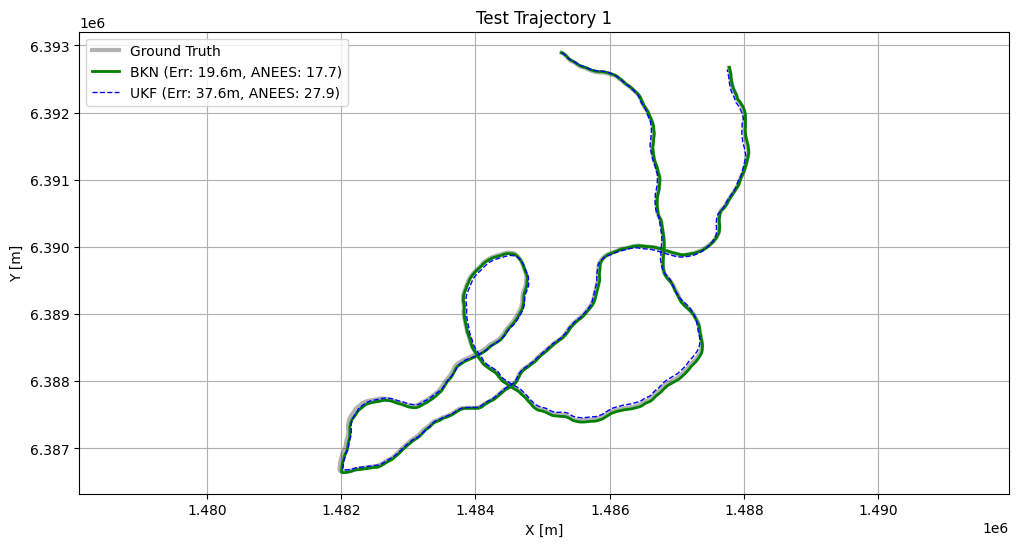

Evaluace:   5%|▌         | 1/20 [00:19<06:18, 19.92s/it]

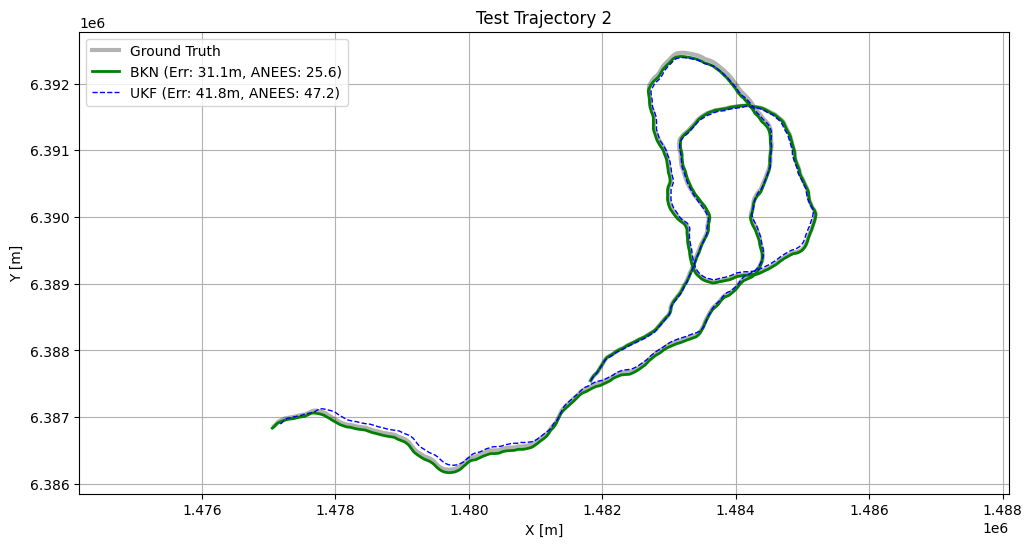

Evaluace:  10%|█         | 2/20 [00:37<05:31, 18.42s/it]

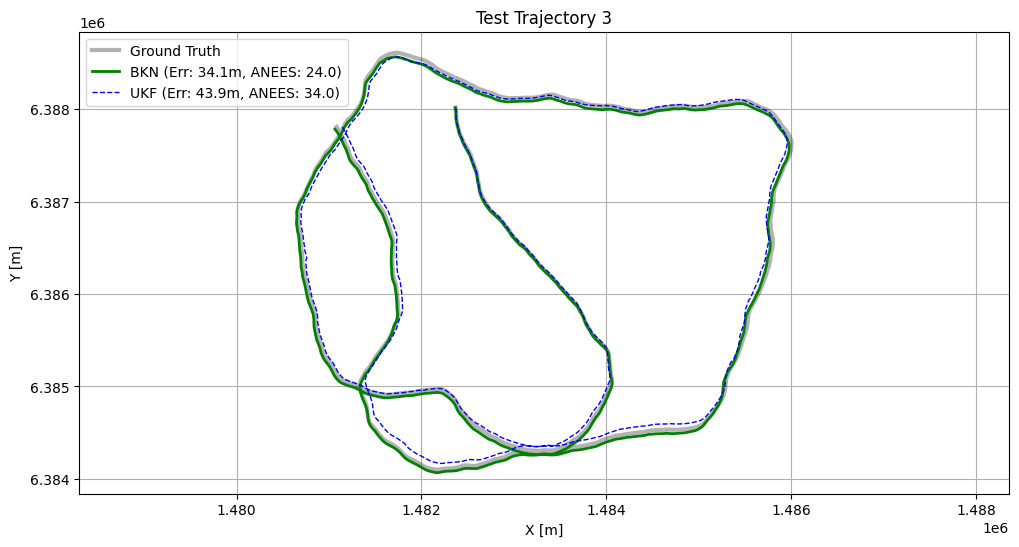

Evaluace:  15%|█▌        | 3/20 [00:55<05:10, 18.27s/it]

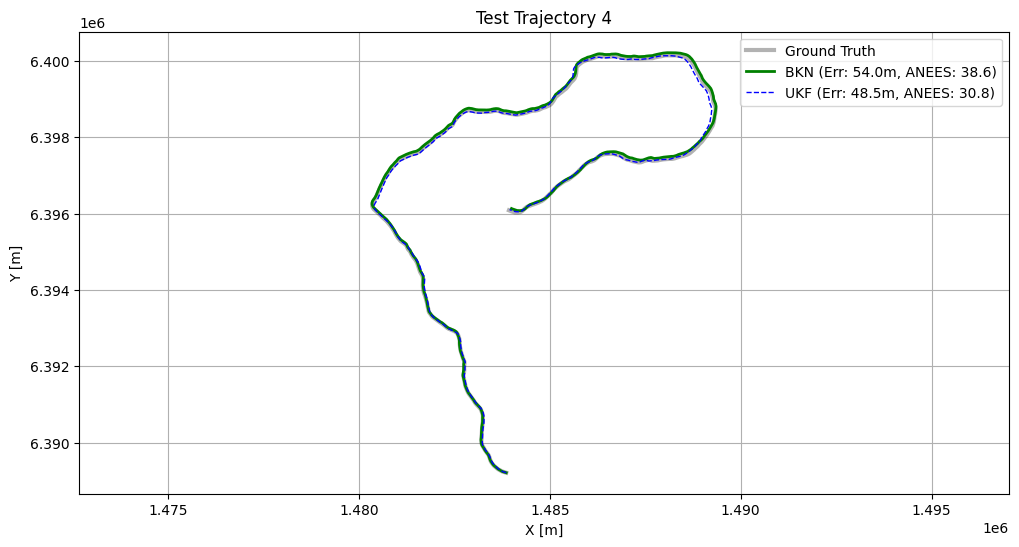

Evaluace:  20%|██        | 4/20 [01:15<05:01, 18.84s/it]

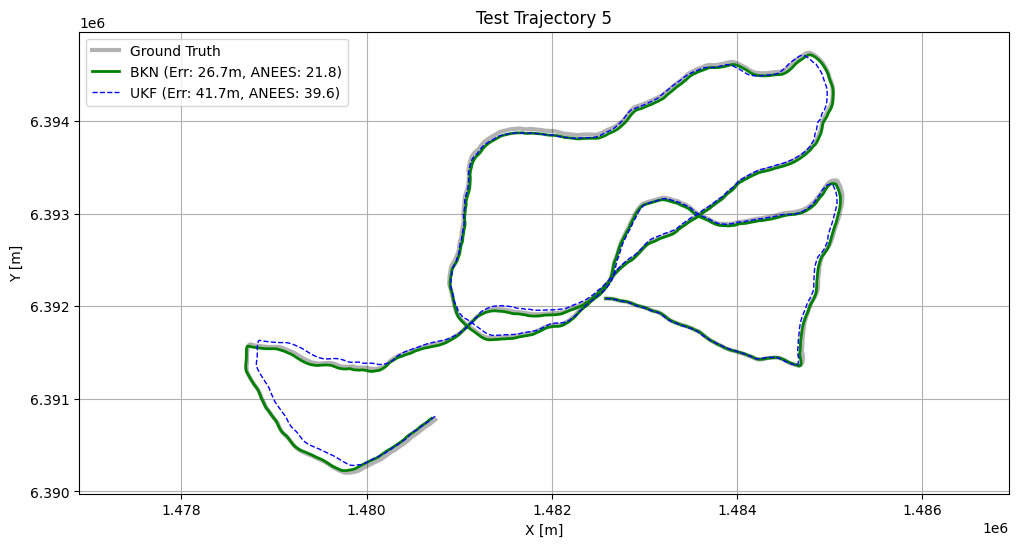

Evaluace:  25%|██▌       | 5/20 [01:32<04:34, 18.30s/it]

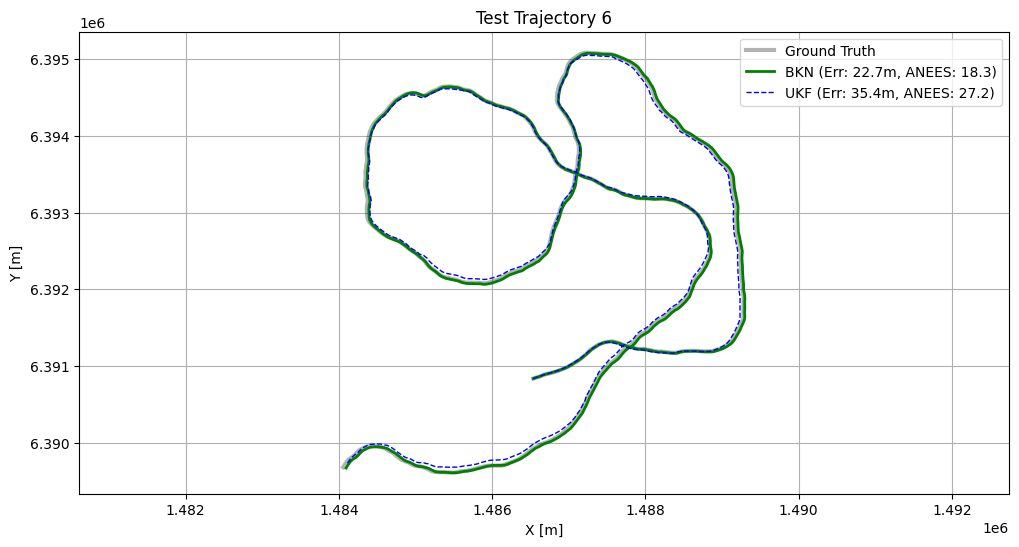

Evaluace:  30%|███       | 6/20 [01:50<04:14, 18.17s/it]

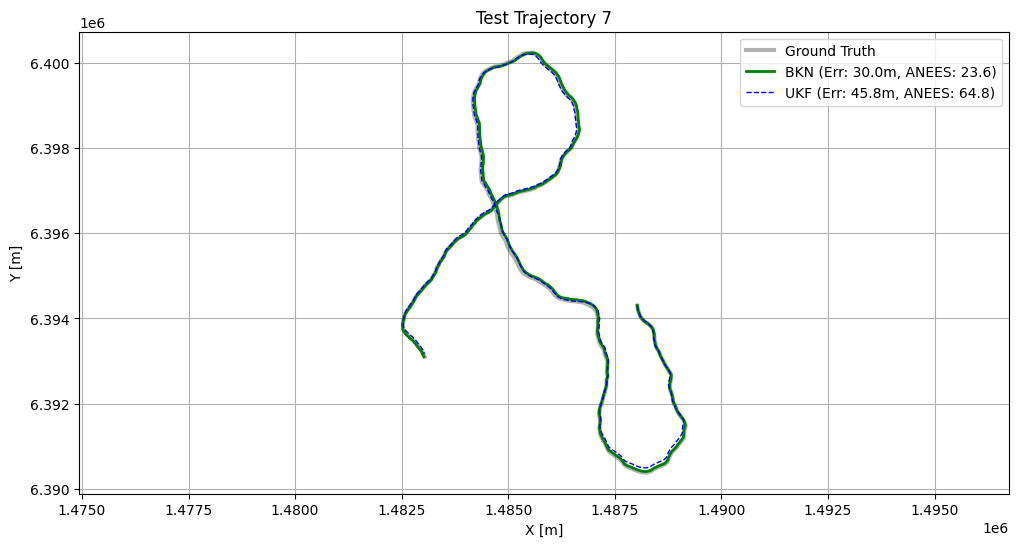

Evaluace:  35%|███▌      | 7/20 [02:09<04:02, 18.63s/it]

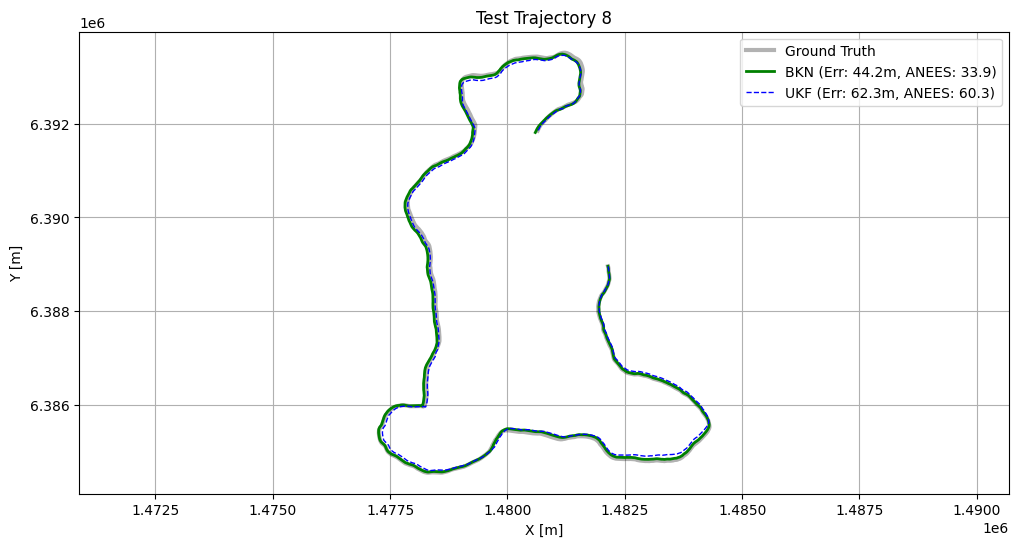

Evaluace:  40%|████      | 8/20 [02:27<03:40, 18.34s/it]

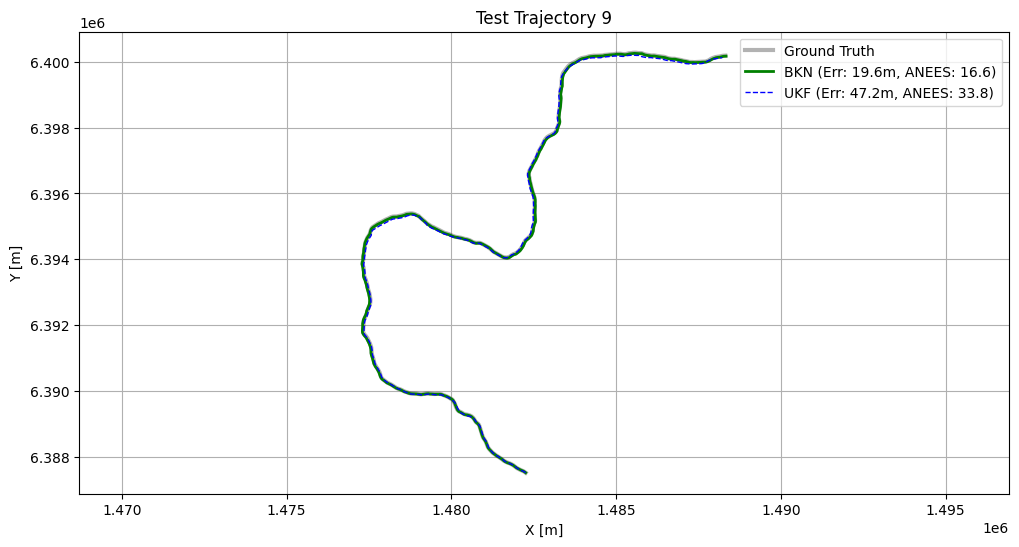

Evaluace:  45%|████▌     | 9/20 [02:45<03:20, 18.19s/it]

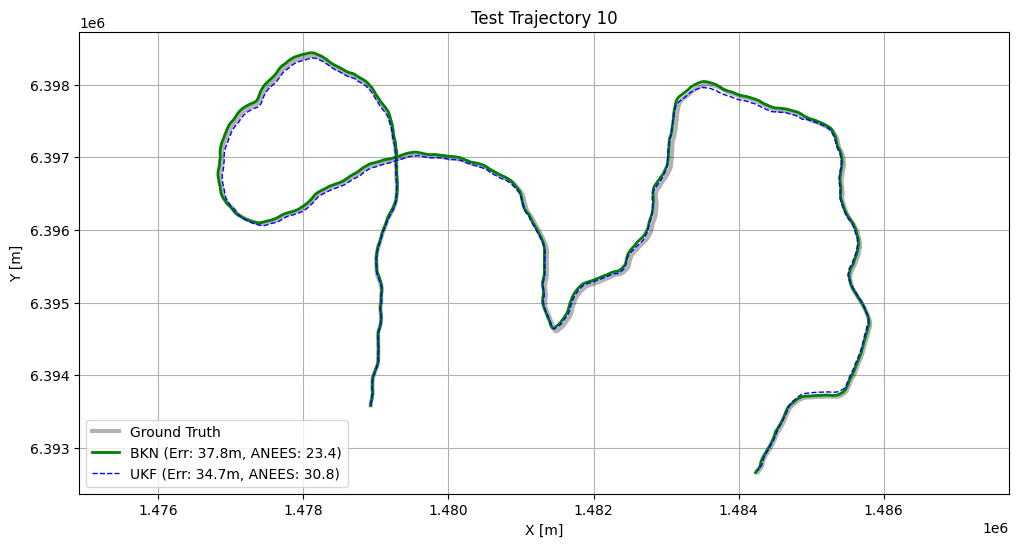

Evaluace:  50%|█████     | 10/20 [03:14<03:14, 19.40s/it]


KeyboardInterrupt: 

In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import Filters
import os
from tqdm import tqdm
from Filters import TAN

# === KONFIGURACE ===
TEST_DATA_PATH = './generated_data_synthetic_controlled/test_set/test.pt'
PLOT_PER_ITERATION = True  # Vykreslovat graf pro každou trajektorii?
MAX_TEST_SAMPLES = 20        # Kolik trajektorií z test setu vyhodnotit
J_EVALUATION = 100           # Počet Monte Carlo vzorků pro BKN (Ensemble size)

print(f"=== VYHODNOCENÍ BKN NA TESTOVACÍ SADĚ (s ANEES) ===")
print(f"Načítám data z: {TEST_DATA_PATH}")

# 1. Načtení Testovací sady
if not os.path.exists(TEST_DATA_PATH):
    raise FileNotFoundError(f"Soubor {TEST_DATA_PATH} neexistuje!")

# Předpokládáme, že 'device' je definováno
if 'device' not in globals():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

test_data = torch.load(TEST_DATA_PATH, map_location=device)
X_test_all = test_data['x']  # Ground Truth [N, Seq, 4]
Y_test_all = test_data['y']  # Measurements [N, Seq, 3]

n_samples = min(X_test_all.shape[0], MAX_TEST_SAMPLES)
print(f"Počet testovacích trajektorií: {n_samples}")
print(f"Ensemble size (BKN): {J_EVALUATION}")
print(f"Délka sekvence: {X_test_all.shape[1]}")
print("Modely: BKN vs. UKF vs. PF vs. APF")

# 2. Inicializace pro sběr dat
detailed_results = []
trajectory_history = []
agg_mse = {"BKN": [], "UKF": [], "PF": [], "APF": []}
agg_pos = {"BKN": [], "UKF": [], "PF": [], "APF": []}
agg_anees = {"BKN": [], "UKF": [], "PF": [], "APF": []} # Nový list pro ANEES

# Ujistíme se, že BKN je v eval módu 
state_knet2.eval() 

# --- POMOCNÁ FUNKCE PRO ANEES ---
def calculate_anees(gt, est, P):
    """
    Vypočítá Average Normalized Estimation Error Squared.
    gt: Ground Truth [T, Dim] (NumPy)
    est: Odhad [T, Dim] (NumPy)
    P: Kovarianční matice [T, Dim, Dim] (NumPy)
    """
    T = min(len(gt), len(est), len(P))
    anees_vals = []
    
    # Oříznutí na stejnou délku
    gt = gt[:T]
    est = est[:T]
    P = P[:T]
    
    for t in range(T):
        e_t = gt[t] - est[t] # Chyba v čase t
        P_t = P[t]
        
        try:
            # Inverze kovariance
            # Přičteme malé epsilon na diagonálu pro numerickou stabilitu, pokud je singulární
            if np.linalg.cond(P_t) > 1e10:
                P_t = P_t + np.eye(P_t.shape[0]) * 1e-6
                
            P_inv = np.linalg.inv(P_t)
            
            # Mahalanobisova vzdálenost: e^T * P^-1 * e
            anees_t = e_t.T @ P_inv @ e_t
            anees_vals.append(anees_t)
        except np.linalg.LinAlgError:
            anees_vals.append(np.nan)
            
    return np.nanmean(anees_vals)

# --- HLAVNÍ SMYČKA ---
for i in tqdm(range(n_samples), desc="Evaluace"):
    
    # A) Příprava dat
    x_gt_tensor = X_test_all[i].to(device)
    y_obs_tensor = Y_test_all[i].to(device)
    
    x_gt = x_gt_tensor.cpu().numpy()
    seq_len = x_gt.shape[0]
    true_init_state = x_gt_tensor[0] 
    
    # --- B) BKN (Ensemble) ---
    with torch.no_grad():
        init_batch = true_init_state.unsqueeze(0).repeat(J_EVALUATION, 1)
        state_knet2.reset(batch_size=J_EVALUATION, initial_state=init_batch)
        
        bkn_preds = []
        y_input_batch = y_obs_tensor.unsqueeze(0).repeat(J_EVALUATION, 1, 1)
        
        for t in range(1, seq_len):
            y_t = y_input_batch[:, t, :]
            x_est, _ = state_knet2.step(y_t) 
            
            # ==============================================================
            # ENSEMBLE BOUNDING (Zabránění explozi náhodné procházky u MC Dropoutu)
            # ==============================================================
            x_est_mean = x_est.mean(dim=0, keepdim=True)
            
            # Podíváme se, jak daleko se vzorky "rozutekly" od průměru
            spread = x_est - x_est_mean
            
            # FYZIKÁLNÍ LIMIT NEJISTOTY (Bounding):
            # Nedovolíme vzorkům, aby se od sebe vzdálily o více než je reálné.
            # Dovolíme obálce mít např. +- 20 metrů v poloze a +- 1 m/s v rychlosti.
            spread[:, 0:2] = torch.clamp(spread[:, 0:2], min=-20.0, max=20.0)
            spread[:, 2:4] = torch.clamp(spread[:, 2:4], min=-1.0, max=1.0)
            
            # Složíme stav zpět: Střední poloha + oříznutá neurčitost
            x_est_corrected = x_est_mean + spread
            
            # Aby se toto omezení projevilo fyzicky v dalším kroku, musíme "stádo" 
            # přepsat i v interních stavech filtru, nikoliv jej jen uložit do historie.
            # (h_prev se neresetuje, takže model si plně zachovává svou skrytou paměť!)
            state_knet2.x_filtered_t_minus_1 = x_est_corrected.detach()
            # ==============================================================
            
            bkn_preds.append(x_est_corrected)
            
        if len(bkn_preds) > 0:
            bkn_preds_tensor = torch.stack(bkn_preds, dim=1) # [J, Seq-1, 4]
            full_bkn_ensemble = torch.cat([init_batch.unsqueeze(1), bkn_preds_tensor], dim=1) # [J, Seq, 4]
            
            # Mean Estimate
            x_est_mean = full_bkn_ensemble.mean(dim=0)
            x_est_bkn = x_est_mean.cpu().numpy()
            
            # --- VÝPOČET KOVARIANCE PRO BKN ---
            # P = 1/(J-1) * sum((x_j - x_mean) * (x_j - x_mean)^T)
            # Vycentrování
            residuals = full_bkn_ensemble - x_est_mean.unsqueeze(0) # [J, Seq, 4]
            # Permute pro batch matmul: [Seq, J, 4] a [Seq, 4, J]
            residuals = residuals.permute(1, 2, 0) # [Seq, 4, J]
            
            # Batch matrix multiplication: (Seq, 4, J) @ (Seq, J, 4) -> (Seq, 4, 4)
            P_bkn_tensor = torch.bmm(residuals, residuals.transpose(1, 2)) / (J_EVALUATION - 1)
            # Přičtení process noise/stabilitu (volitelné, BKN variance je epistemická)
            P_bkn = P_bkn_tensor.cpu().numpy()
            
        else:
            x_est_bkn = x_gt
            P_bkn = np.eye(4)[np.newaxis, :, :].repeat(len(x_gt), axis=0)

    # --- C) Klasické Filtry ---
    
    # UKF
    ukf_ideal = Filters.UnscentedKalmanFilter(system_model)
    ukf_res = ukf_ideal.process_sequence(y_seq=y_obs_tensor, Ex0=true_init_state, P0=system_model.P0)
    x_est_ukf = ukf_res['x_filtered'].cpu().numpy()
    # Získání P pro UKF (zkusíme různé klíče)
    P_ukf = ukf_res.get('P_filtered', ukf_res.get('P', None))
    if P_ukf is not None: P_ukf = P_ukf.cpu().numpy()

    # PF
    pf = TAN.ParticleFilterTAN(system_model, num_particles=1000) 
    pf_res = pf.process_sequence(y_seq=y_obs_tensor, Ex0=true_init_state, P0=system_model.P0)
    x_est_pf = pf_res['x_filtered'].cpu().numpy()
    P_pf = pf_res.get('P_filtered', pf_res.get('P', None))
    if P_pf is not None: P_pf = P_pf.cpu().numpy()

    # APF
    apf = TAN.AuxiliaryParticleFilterTAN(system_model, num_particles=2000) 
    apf_res = apf.process_sequence(y_seq=y_obs_tensor, Ex0=true_init_state, P0=system_model.P0)
    x_est_apf = apf_res['x_filtered'].cpu().numpy()
    P_apf = apf_res.get('P_filtered', apf_res.get('P', None))
    if P_apf is not None: P_apf = P_apf.cpu().numpy()
    
    # --- D) Výpočet chyb a ANEES ---
    min_len = min(len(x_gt), len(x_est_bkn), len(x_est_ukf))
    
    def calc_metrics(est, gt, P_mat):
        diff = est[:min_len] - gt[:min_len]
        mse = np.mean(np.sum(diff[:, :2]**2, axis=1)) 
        pos_err = np.mean(np.sqrt(diff[:, 0]**2 + diff[:, 1]**2))
        
        anees = np.nan
        if P_mat is not None:
            anees = calculate_anees(gt[:min_len], est[:min_len], P_mat[:min_len])
            
        return mse, pos_err, anees

    # Calculate for all
    mse_bkn, pos_bkn, anees_bkn = calc_metrics(x_est_bkn, x_gt, P_bkn)
    mse_ukf, pos_ukf, anees_ukf = calc_metrics(x_est_ukf, x_gt, P_ukf)
    mse_pf, pos_pf, anees_pf = calc_metrics(x_est_pf, x_gt, P_pf)
    mse_apf, pos_apf, anees_apf = calc_metrics(x_est_apf, x_gt, P_apf)
    
    # Uložení
    agg_mse["BKN"].append(mse_bkn); agg_pos["BKN"].append(pos_bkn); agg_anees["BKN"].append(anees_bkn)
    agg_mse["UKF"].append(mse_ukf); agg_pos["UKF"].append(pos_ukf); agg_anees["UKF"].append(anees_ukf)
    agg_mse["PF"].append(mse_pf);   agg_pos["PF"].append(pos_pf);   agg_anees["PF"].append(anees_pf)
    agg_mse["APF"].append(mse_apf); agg_pos["APF"].append(pos_apf); agg_anees["APF"].append(anees_apf)

    detailed_results.append({
        "Run_ID": i + 1,
        "BKN_PosErr": pos_bkn, "BKN_ANEES": anees_bkn,
        "UKF_PosErr": pos_ukf, "UKF_ANEES": anees_ukf,
        "PF_PosErr": pos_pf,   "PF_ANEES": anees_pf,
        "APF_PosErr": pos_apf, "APF_ANEES": anees_apf
    })
    
    if i < 2:  # Uložíme detailní časovou historii pro první 2 trajektorie
        trajectory_history.append({
            "gt": x_gt,
            "bkn_est": x_est_bkn,
            "bkn_P": P_bkn,
            "ukf_est": x_est_ukf,
            "ukf_P": P_ukf
        })
    # E) Vykreslení
    if PLOT_PER_ITERATION:
        fig = plt.figure(figsize=(12, 6))
        plt.plot(x_gt[:, 0], x_gt[:, 1], 'k-', linewidth=3, alpha=0.3, label='Ground Truth')
        plt.plot(x_est_bkn[:, 0], x_est_bkn[:, 1], 'g-', linewidth=2, label=f'BKN (Err: {pos_bkn:.1f}m, ANEES: {anees_bkn:.1f})')
        plt.plot(x_est_ukf[:, 0], x_est_ukf[:, 1], 'b--', linewidth=1, label=f'UKF (Err: {pos_ukf:.1f}m, ANEES: {anees_ukf:.1f})')
        # Pro přehlednost vykreslíme jen BKN a UKF, případně odkomentujte PF/APF
        # plt.plot(x_est_pf[:, 0], x_est_pf[:, 1], 'r:', linewidth=1, alpha=0.6, label='PF')
        plt.title(f"Test Trajectory {i+1}")
        plt.xlabel("X [m]")
        plt.ylabel("Y [m]")
        plt.legend()
        plt.axis('equal')
        plt.grid(True)
        plt.show()

# --- VÝPIS VÝSLEDKŮ ---
df_results = pd.DataFrame(detailed_results)
print("\n" + "="*120)
print(f"DETAILNÍ VÝSLEDKY (Pozice v metrech | ANEES - ideál ~4.0)")
print("="*120)
pd.options.display.float_format = '{:,.2f}'.format
print(df_results[["Run_ID", "BKN_PosErr", "BKN_ANEES", "UKF_PosErr", "UKF_ANEES", "PF_PosErr", "APF_PosErr"]])

print("\n" + "="*120)
print(f"SOUHRNNÁ STATISTIKA ({n_samples} trajektorií)")
print("="*120)

def get_stats(key):
    return (np.nanmean(agg_mse[key]), np.nanstd(agg_mse[key]), 
            np.nanmean(agg_pos[key]), np.nanstd(agg_pos[key]),
            np.nanmean(agg_anees[key]), np.nanstd(agg_anees[key]))

bkn_s = get_stats("BKN")
ukf_s = get_stats("UKF")
pf_s = get_stats("PF")
apf_s = get_stats("APF")

# Formátování tabulky
header = f"{'Model':<10} | {'Pos Error [m] (Mean ± Std)':<30} | {'ANEES (Mean ± Std)':<30}"
print(header)
print("-" * len(header))
print(f"{'BKN':<10} | {bkn_s[2]:.2f} ± {bkn_s[3]:.2f} m {'':<14} | {bkn_s[4]:.2f} ± {bkn_s[5]:.2f}")
print(f"{'UKF':<10} | {ukf_s[2]:.2f} ± {ukf_s[3]:.2f} m {'':<14} | {ukf_s[4]:.2f} ± {ukf_s[5]:.2f}")
print(f"{'PF':<10} | {pf_s[2]:.2f} ± {pf_s[3]:.2f} m {'':<14} | {pf_s[4]:.2f} ± {pf_s[5]:.2f}")
print(f"{'APF':<10} | {apf_s[2]:.2f} ± {apf_s[3]:.2f} m {'':<14} | {apf_s[4]:.2f} ± {apf_s[5]:.2f}")
print("="*120)

# Grafické porovnání (Boxplot Position Error)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.boxplot([agg_pos["BKN"], agg_pos["UKF"], agg_pos["PF"]], labels=['BKN', 'UKF', 'PF'], patch_artist=True, boxprops=dict(facecolor='lightblue'))
plt.title("Position Error [m]")
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# Grafické porovnání (Boxplot ANEES)
plt.subplot(1, 2, 2)
# Filtrujeme NaN pro boxplot
anees_data = [
    [x for x in agg_anees["BKN"] if not np.isnan(x)],
    [x for x in agg_anees["UKF"] if not np.isnan(x)],
    [x for x in agg_anees["PF"] if not np.isnan(x)]
]
plt.boxplot(anees_data, labels=['BKN', 'UKF', 'PF'], patch_artist=True, boxprops=dict(facecolor='lightgreen'))
plt.axhline(y=4.0, color='r', linestyle='--', label='Ideal (4.0)')
plt.title("ANEES (Consistency)")
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


import numpy as np
import matplotlib.pyplot as plt

# Zkontrolujeme, zda máme uložená data z předchozí buňky
if 'trajectory_history' not in globals() or len(trajectory_history) < 2:
    print("⚠️ Chyba: Chybí data 'trajectory_history'. Ujisti se, že jsi provedl úpravu v hlavní smyčce.")
else:
    for traj_idx in range(2):
        data = trajectory_history[traj_idx]
        
        gt = data["gt"]
        bkn_est = data["bkn_est"]
        bkn_P = data["bkn_P"]
        ukf_est = data["ukf_est"]
        ukf_P = data["ukf_P"]
        
        seq_len = min(len(gt), len(bkn_est), len(ukf_est))
        time_steps = np.arange(seq_len)
        
        # Výpočet odchylek (Error = Odhad - Skutečnost)
        err_bkn_x = bkn_est[:seq_len, 0] - gt[:seq_len, 0]
        err_bkn_y = bkn_est[:seq_len, 1] - gt[:seq_len, 1]
        
        err_ukf_x = ukf_est[:seq_len, 0] - gt[:seq_len, 0]
        err_ukf_y = ukf_est[:seq_len, 1] - gt[:seq_len, 1]
        
        # Výpočet 3-sigma mezí z kovariančních matic
        # (index 0,0 je variance X; index 1,1 je variance Y)
        std_bkn_x = np.sqrt(bkn_P[:seq_len, 0, 0])
        std_bkn_y = np.sqrt(bkn_P[:seq_len, 1, 1])
        
        std_ukf_x = np.sqrt(ukf_P[:seq_len, 0, 0])
        std_ukf_y = np.sqrt(ukf_P[:seq_len, 1, 1])

        # --- VYKRESLOVÁNÍ ---
        fig, axs = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
        fig.suptitle(f'Trajektorie {traj_idx + 1}: Analýza Konzistence (Chyba vs. 3σ Obálka)', fontsize=16)

        # 1. BKN - Poloha X
        axs[0, 0].plot(time_steps, err_bkn_x, 'g-', linewidth=2, label='BKN Error X')
        axs[0, 0].fill_between(time_steps, -3*std_bkn_x, 3*std_bkn_x, color='green', alpha=0.2, label='BKN 3σ Bounds')
        axs[0, 0].axhline(0, color='black', linestyle='--', linewidth=1)
        axs[0, 0].set_title('Bayesian KalmanNet - Chyba v ose X')
        axs[0, 0].set_ylabel('Chyba [m]')
        axs[0, 0].legend(loc='upper right')
        axs[0, 0].grid(True, linestyle=':', alpha=0.7)

        # 2. BKN - Poloha Y
        axs[1, 0].plot(time_steps, err_bkn_y, 'g-', linewidth=2, label='BKN Error Y')
        axs[1, 0].fill_between(time_steps, -3*std_bkn_y, 3*std_bkn_y, color='green', alpha=0.2, label='BKN 3σ Bounds')
        axs[1, 0].axhline(0, color='black', linestyle='--', linewidth=1)
        axs[1, 0].set_title('Bayesian KalmanNet - Chyba v ose Y')
        axs[1, 0].set_xlabel('Časový krok (k)')
        axs[1, 0].set_ylabel('Chyba [m]')
        axs[1, 0].legend(loc='upper right')
        axs[1, 0].grid(True, linestyle=':', alpha=0.7)

        # 3. UKF - Poloha X
        axs[0, 1].plot(time_steps, err_ukf_x, 'b-', linewidth=2, label='UKF Error X')
        axs[0, 1].fill_between(time_steps, -3*std_ukf_x, 3*std_ukf_x, color='blue', alpha=0.2, label='UKF 3σ Bounds')
        axs[0, 1].axhline(0, color='black', linestyle='--', linewidth=1)
        axs[0, 1].set_title('Unscented Kalman Filter - Chyba v ose X')
        axs[0, 1].legend(loc='upper right')
        axs[0, 1].grid(True, linestyle=':', alpha=0.7)

        # 4. UKF - Poloha Y
        axs[1, 1].plot(time_steps, err_ukf_y, 'b-', linewidth=2, label='UKF Error Y')
        axs[1, 1].fill_between(time_steps, -3*std_ukf_y, 3*std_ukf_y, color='blue', alpha=0.2, label='UKF 3σ Bounds')
        axs[1, 1].axhline(0, color='black', linestyle='--', linewidth=1)
        axs[1, 1].set_title('Unscented Kalman Filter - Chyba v ose Y')
        axs[1, 1].set_xlabel('Časový krok (k)')
        axs[1, 1].legend(loc='upper right')
        axs[1, 1].grid(True, linestyle=':', alpha=0.7)

        # Sladění Y-os pro spravedlivé porovnání mezi BKN a UKF
        max_y_val_x = max(np.max(np.abs(err_bkn_x)), np.max(3*std_bkn_x), np.max(np.abs(err_ukf_x)), np.max(3*std_ukf_x)) * 1.1
        max_y_val_y = max(np.max(np.abs(err_bkn_y)), np.max(3*std_bkn_y), np.max(np.abs(err_ukf_y)), np.max(3*std_ukf_y)) * 1.1
        
        axs[0, 0].set_ylim(-max_y_val_x, max_y_val_x)
        axs[0, 1].set_ylim(-max_y_val_x, max_y_val_x)
        axs[1, 0].set_ylim(-max_y_val_y, max_y_val_y)
        axs[1, 1].set_ylim(-max_y_val_y, max_y_val_y)

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()